# Receipt Extraction: Training, Evaluation, and Inference

Choose one workflow per fresh session:
- **Training and evaluation:** run Setup through Fine-tuned evaluation in order. SROIE is an optional, separate header experiment.
- **Standalone PDF prediction:** start at Predict your own PDF on Kaggle. These predictions are not OCR-grounded.
- **API validation:** start at Minimal Kaggle API validation. The API subprocess must be the only GPU model owner.

Do not use Run All across these workflows. Keep receipt files and credentials private.

Saved outputs are historical captures, not results from rerunning this cleaned notebook.

## 0. Setup

This section keeps installation and imports together so the notebook can start cleanly on Colab or a local GPU machine. The install step is intentionally a no-op outside Colab, and the environment checks should be the first things you run after the notebook opens.


In [1]:
# Install once. If this cell just ran for the first time: Runtime → Restart session, then run from the top.
# Do not `import unsloth` before this finishes, and do not pip-install again after Unsloth is imported.
%pip install -q unsloth datasets transformers peft trl bitsandbytes accelerate wandb pillow json-repair huggingface_hub pandas matplotlib



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.1/81.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.4/25.4 MB 65.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 92.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 43.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 76.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 81.9 MB/s eta 0:00:00:00:01
   ━━━━━━━

In [2]:
import hashlib
import json
import math
import os
import re
import sys
import time
from collections import defaultdict
from difflib import SequenceMatcher
from datetime import datetime
from io import BytesIO
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Unsloth must be imported before transformers/trl/peft or it skips its patches
# and later SFTTrainer requires a formatting_func that vision collators do not use.
import unsloth  # noqa: F401


IN_COLAB = "google.colab" in sys.modules

os.environ.setdefault(
    "WANDB_MODE",
    "disabled" if not os.environ.get("WANDB_API_KEY") else os.environ.get("WANDB_MODE", "online"),
)

try:
    import torch
    HAS_GPU = torch.cuda.is_available()
except Exception:
    torch = None
    HAS_GPU = False

# Inference: keep 1008 long-edge so OCR/grounding still sees small print.
# Training: cap vision tokens. Qwen2.5-VL ≈ 1 token per 28×28 pixels.
MODEL_ID = os.environ.get("MODEL_ID", "unsloth/Qwen2.5-VL-3B-Instruct-bnb-4bit")
HF_BASE_ID = os.environ.get("HF_BASE_ID", "Qwen/Qwen2.5-VL-3B-Instruct")
ADAPTER_DIR = Path(os.environ.get("ADAPTER_DIR", "outputs/lora"))
HF_ADAPTER_REPO = os.environ.get("HF_ADAPTER_REPO", "mahesh-nallada/vlm-receipt-extraction-lora")
LONG_EDGE = 1008
MAX_PIXELS = 1008 * 28 * 28
EVAL_MIN_PIXELS = 256 * 28 * 28
TRAIN_VISION_TOKENS = int(os.environ.get("TRAIN_VISION_TOKENS", "768"))
TRAIN_MIN_PIXELS = 128 * 28 * 28
TRAIN_MAX_PIXELS = TRAIN_VISION_TOKENS * 28 * 28
# 512 vis + prompt + compact CORD JSON. 3072 is enough for long receipts on T4
# after the eval weights are freed. Override with TRAIN_MAX_SEQ if needed.
TRAIN_MAX_SEQ = int(os.environ.get("TRAIN_MAX_SEQ", "3072"))
LORA_R, LORA_ALPHA, LORA_DROPOUT = 16, 32, 0.0
EVAL_N = int(os.environ.get("EVAL_N", "8"))
SANITY_TOLERANCE = 0.05
WORK = Path("pipeline_out")
WORK.mkdir(exist_ok=True)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [3]:
def smart_hw(width, height, min_pixels, max_pixels, factor=28):
    """Qwen2.5-VL smart_resize: sides multiple of 28, pixels in [min, max]."""
    h = max(factor, int(round(height / factor) * factor))
    w = max(factor, int(round(width / factor) * factor))
    if h * w > max_pixels:
        scale = math.sqrt(max_pixels / max(1, height * width))
        h = max(factor, int(math.floor(height * scale / factor) * factor))
        w = max(factor, int(math.floor(width * scale / factor) * factor))
    elif h * w < min_pixels:
        scale = math.sqrt(min_pixels / max(1, height * width))
        h = max(factor, int(math.ceil(height * scale / factor) * factor))
        w = max(factor, int(math.ceil(width * scale / factor) * factor))
    return int(w), int(h)


def resize_image(image, min_pixels, max_pixels):
    from PIL import Image as PILImage

    if not isinstance(image, PILImage.Image):
        image = image.convert("RGB") if hasattr(image, "convert") else PILImage.fromarray(image).convert("RGB")
    else:
        image = image.convert("RGB")
    w, h = image.size
    nw, nh = smart_hw(w, h, min_pixels, max_pixels)
    if (nw, nh) != (w, h):
        image = image.resize((nw, nh), PILImage.Resampling.BICUBIC)
    return image


def vision_token_count(image):
    w, h = image.size
    return max(1, (h // 28) * (w // 28))

print(
    "colab", IN_COLAB, "cuda", HAS_GPU, "model", MODEL_ID,
    "train_vis", TRAIN_VISION_TOKENS, "train_max_seq", TRAIN_MAX_SEQ, "epochs", os.environ.get("TRAIN_EPOCHS", "2"), "vision_lora", os.environ.get("TRAIN_VISION_LAYERS", "0"),
)

def _show_df(df, title=None):
    if title:
        print(title)
    if pd is None:
        print(df)
        return
    try:
        display(df)
    except Exception:
        print(df.to_string(index=False))


def _style_plot():
    if plt is None:
        return
    plt.rcParams.update({
        "figure.figsize": (10, 4),
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
    })


colab False cuda True model unsloth/Qwen2.5-VL-3B-Instruct-bnb-4bit train_vis 768 train_max_seq 3072 epochs 2 vision_lora 0


## 0.1 Utility helpers

This block groups the shared image, display, and plotting helpers separately from the environment setup so the top of the notebook is easier to scan.


## 1. Schema, CORD mapping, JSON parse

CORD has no store-name or date labels. Those targets are `null`. Dates in the live API are ISO `YYYY-MM-DD`. Numbers are JSON numbers.


#### Helpers: `parse_qty`, `_null_placeholder`


In [ ]:
EXTRACT_PROMPT = (
    "Extract the receipt as JSON with keys store_name, date (YYYY-MM-DD), "
    "line_items (name, qty, unit_price, amount), subtotal, tax, total. "
    "Copy only text visible on the page. Never guess or copy a product name into store_name. "
    "Only return store_name or date when clearly shown; use null for unknown or placeholder text. "
    "qty is the printed quantity; keep it null when not printed. "
    "unit_price is the price for one unit; amount is the total for the line. Do not swap them. "
    "Use null when a field is absent. Numbers must be JSON numbers, not strings. Do not guess."
)

QTY_RE = re.compile(r"[-+]?\d+(?:[.,]\d+)?")
FENCE = re.compile(r"```(?:json)?\s*(.*?)```", re.DOTALL)

def parse_qty(raw):
    if raw is None:
        return None
    if isinstance(raw, (int, float)) and not isinstance(raw, bool):
        return float(raw)
    match = QTY_RE.search(str(raw))
    return float(match.group(0).replace(",", ".")) if match else None


from pydantic import BaseModel, ConfigDict, Field, field_validator

_NULL_STRINGS = {"", "null", "none", "unknown", "n/a", "na", "******", "-"}


def _null_placeholder(value):
    return None if isinstance(value, str) and value.strip().casefold() in _NULL_STRINGS else value


#### Helpers: `NotebookLineItem`, `NotebookReceipt`, `as_menu_list`


In [ ]:
class NotebookLineItem(BaseModel):
    model_config = ConfigDict(extra="forbid")

    name: str
    qty: float | None = None
    unit_price: float | None = None
    amount: float | None = None

    @field_validator("qty", mode="before")
    @classmethod
    def normalize_qty(cls, value):
        return parse_qty(value)

    @field_validator("unit_price", "amount", mode="before")
    @classmethod
    def normalize_money(cls, value):
        return parse_money(value)


class NotebookReceipt(BaseModel):
    model_config = ConfigDict(extra="forbid")

    store_name: str | None = None
    date: str | None = None
    line_items: list[NotebookLineItem] = Field(default_factory=list)
    subtotal: float | None = None
    tax: float | None = None
    total: float | None = None

    @field_validator("store_name", "date", mode="before")
    @classmethod
    def normalize_placeholder(cls, value):
        return _null_placeholder(value)

    @field_validator("date")
    @classmethod
    def normalize_date(cls, value):
        if value is None:
            return None
        for date_format in ("%Y-%m-%d", "%d/%m/%Y", "%d-%m-%Y", "%d.%m.%Y"):
            try:
                return datetime.strptime(value.strip(), date_format).date().isoformat()
            except ValueError:
                continue
        return None

    @field_validator("subtotal", "tax", "total", mode="before")
    @classmethod
    def normalize_money(cls, value):
        return parse_money(value)


def as_menu_list(menu):
    if menu is None:
        return []
    if isinstance(menu, dict):
        return [menu]
    return [item for item in menu if isinstance(item, dict)] if isinstance(menu, list) else []


#### Helpers: `flatten_menu_items`, `ground_truth_of`


In [ ]:
"""
{
  "gt_parse": {
    "menu": [
      {"nm": "Nasi Goreng", "cnt": "1", "unitprice": "15000", "price": "15000"},
      {"nm": "Es Teh", "cnt": "2", "unitprice": "3000", "price": "6000"}
    ],
    "sub_total": {
      "subtotal_price": "21000",
      "tax_price": "2100"
    },
    "total": {
      "total_price": "23100"
    }
  }
}
"""

def flatten_menu_items(menu):
    """Return parent menu items and nested sub-items in source order."""
    flattened = []
    for item in as_menu_list(menu):
        flattened.append(item)
        flattened.extend(flatten_menu_items(item.get("sub")))
    return flattened


def ground_truth_of(row):
    raw = row["ground_truth"]
    payload = json.loads(raw) if isinstance(raw, str) else raw
    return payload["gt_parse"]


#### Helpers: `split_hash`, `extract_json_object`


In [ ]:
def split_hash(ids):
    return hashlib.sha256(",".join(ids).encode()).hexdigest()[:16]


"""
1. Prose + JSON (most common)

Here is the receipt:
{"store_name": "Oak Cafe", "date": "2024-03-12", "line_items": [{"name": "Latte", "qty": 2, "unit_price": 4.5, "amount": 9.0}], "subtotal": 9.0, "tax": 0.7, "total": 9.7}
Returns the {...} only. The “Here is the receipt:” line is dropped.


2. Markdown fence

```json
{"store_name": null, "date": null, "line_items": [], "subtotal": 12.0, "tax": 1.2, "total": 13.2}

`FENCE` takes the block inside ` ```json `, then the same `{` … `}` slice.

3. No object → `None`

```text
I cannot read the image.
find("{") fails, so parse raises and the notebook does the one repair generate.

"""
def extract_json_object(text):
    fenced = FENCE.search(text)
    candidate = fenced.group(1) if fenced else text
    start, end = candidate.find("{"), candidate.rfind("}")
    if start == -1 or end <= start:
        return None
    return candidate[start : end + 1]


#### Helpers: `parse_model_output`


In [ ]:
def parse_model_output(text):
    blob = extract_json_object(text or "")
    if blob is None:
        raise ValueError("model output is not JSON")
    try:
        loaded = json.loads(blob)
    except json.JSONDecodeError:
        try:
            from json_repair import repair_json

            loaded = json.loads(repair_json(blob))
        except Exception as exc:
            raise ValueError("model output is not valid JSON") from exc
    if isinstance(loaded.get("store_name"), str) and loaded["store_name"].strip().casefold() in {"", "null", "none", "unknown", "n/a", "na", "******", "-"}:
        loaded["store_name"] = None
    if isinstance(loaded.get("date"), str) and loaded["date"].strip().casefold() in {"", "null", "none", "unknown", "n/a", "na", "******", "-"}:
        loaded["date"] = None
    if not isinstance(loaded, dict):
        raise ValueError("model output must be an object")
    loaded = NotebookReceipt.model_validate(loaded).model_dump()
    items = []
    for item in loaded.get("line_items") or []:
        if not isinstance(item, dict) or not str(item.get("name") or "").strip():
            continue
        items.append(
            {
                "name": str(item["name"]).strip(),
                "qty": parse_qty(item.get("qty")),
                "unit_price": parse_money(item.get("unit_price")),
                "amount": parse_money(item.get("amount")),
            }
        )
    date = loaded.get("date")
    if date is not None:
        datetime.strptime(str(date), "%Y-%m-%d")
    store = loaded.get("store_name")
    return {
        "store_name": store.strip() if isinstance(store, str) and store.strip() else None,
        "date": date,
        "line_items": items,
        "subtotal": parse_money(loaded.get("subtotal")),
        "tax": parse_money(loaded.get("tax")),
        "total": parse_money(loaded.get("total")),
    }


#### Helpers: `_has_idr_marker`, `_cord_source_locale`


In [ ]:
import os
import re


CORD_CURRENCY_LOCALE = os.environ.get("CORD_CURRENCY_LOCALE", "en-US")


def _has_idr_marker(value):
    if isinstance(value, dict):
        return any(_has_idr_marker(item) for item in value.values())
    if isinstance(value, (list, tuple)):
        return any(_has_idr_marker(item) for item in value)
    if not isinstance(value, str):
        return False
    text = value.strip().casefold()
    return text.startswith("rp") or text.startswith("idr")


def _cord_source_locale(gt_parse):
    return "id-ID" if _has_idr_marker(gt_parse) else CORD_CURRENCY_LOCALE


#### Helpers: `parse_money`


In [ ]:
def parse_money(raw, locale=None):
    if raw is None:
        return None
    if isinstance(raw, (int, float)) and not isinstance(raw, bool):
        return float(raw)
    if isinstance(raw, (list, tuple)):
        values = [parse_money(value, locale=locale) for value in raw]
        values = [value for value in values if value is not None]
        if not values or any(abs(value - values[0]) > 1e-9 for value in values[1:]):
            return None
        return values[0]

    text = str(raw).strip().replace("@", "").replace(" ", "")
    negative = text.startswith("(") and text.endswith(")")
    if negative:
        text = text[1:-1]
    lower_text = text.casefold()
    idr_value = lower_text.startswith("rp") or lower_text.startswith("idr")
    if lower_text.startswith("rp."):
        text = text[3:]
    elif lower_text.startswith("rp") or lower_text.startswith("idr"):
        text = text[2:] if lower_text.startswith("rp") else text[3:]
    text = re.sub(r"(?i)^(?:usd|eur|gbp)", "", text)
    text = re.sub(r"[$€£¥₹]", "", text)
    if not text:
        return None
    if locale is None:
        locale = "id-ID" if idr_value else CORD_CURRENCY_LOCALE

    decimal_sep = "," if locale.casefold() in {"id-id", "de-de", "fr-fr", "es-es", "it-it", "pt-br"} else "."
    group_sep = "." if decimal_sep == "," else ","
    has_decimal = decimal_sep in text
    has_group = group_sep in text

    if has_decimal and has_group:
        if text.rfind(decimal_sep) > text.rfind(group_sep):
            text = text.replace(group_sep, "").replace(decimal_sep, ".")
        else:
            text = text.replace(decimal_sep, "").replace(group_sep, ".")
    elif has_group:
        parts = text.split(group_sep)
        grouped = len(parts) > 1 and 1 <= len(parts[0].lstrip("+-")) <= 3 and all(len(part) == 3 and part.isdigit() for part in parts[1:])
        if grouped:
            text = "".join(parts)
        elif decimal_sep != group_sep:
            text = text.replace(group_sep, ".")
    elif has_decimal and text.count(decimal_sep) > 1:
        parts = text.split(decimal_sep)
        grouped = 1 <= len(parts[0].lstrip("+-")) <= 3 and all(len(part) == 3 and part.isdigit() for part in parts[1:])
        if grouped:
            text = "".join(parts)
        else:
            return None
    elif has_decimal:
        text = text.replace(decimal_sep, ".")

    try:
        value = float(text)
        return -value if negative else value
    except ValueError:
        return None


#### Helpers: `cord_to_schema`


In [ ]:
def cord_to_schema(gt_parse, locale=None):
    locale = locale or _cord_source_locale(gt_parse)
    items = []
    for item in flatten_menu_items(gt_parse.get("menu")):
        name = item.get("nm")
        if not isinstance(name, str) or not name.strip():
            continue
        items.append(
            {
                "name": name.strip(),
                "qty": parse_qty(item.get("cnt")),
                "unit_price": parse_money(item.get("unitprice"), locale=locale),
                "amount": parse_money(item.get("price"), locale=locale),
            }
        )

    raw_sub = gt_parse.get("sub_total")
    sub = raw_sub if isinstance(raw_sub, dict) else {}
    raw_tot = gt_parse.get("total")
    tot = raw_tot if isinstance(raw_tot, dict) else {}
    return {
        "store_name": None,
        "date": None,
        "line_items": items,
        "subtotal": parse_money(sub.get("subtotal_price"), locale=locale),
        "tax": parse_money(sub.get("tax_price"), locale=locale),
        "total": parse_money(tot.get("total_price"), locale=locale),
    }


_EXTRACT_LOCALE_INSTRUCTIONS = (
    "\nUse the visible currency convention for amounts. For Rp/IDR receipts, periods group thousands "
    "and commas are decimal separators. Otherwise use the "
    f"{CORD_CURRENCY_LOCALE} locale. Emit numeric JSON values, not formatted strings."
 )
if _EXTRACT_LOCALE_INSTRUCTIONS not in EXTRACT_PROMPT:
    EXTRACT_PROMPT += _EXTRACT_LOCALE_INSTRUCTIONS


#### Helpers: `cord_to_schema`


In [ ]:
if "_cord_to_schema_annotation_base" not in globals():
    _cord_to_schema_annotation_base = cord_to_schema


def cord_to_schema(gt_parse, locale=None):
    target = _cord_to_schema_annotation_base(gt_parse, locale=locale)
    for field in ("store_name", "date", "subtotal", "tax", "total"):
        if target.get(field) is None:
            target.pop(field)
    for item in target.get("line_items", []):
        for field in ("qty", "unit_price", "amount"):
            if item.get(field) is None:
                item.pop(field)
    return target


CORD_TRAINING_TARGET_NOTE = (
    " CORD fields omitted from a target are unannotated, not negative labels. "
    "At inference, omit fields that are not legible; the receipt parser fills missing optional fields with null."
 )
if CORD_TRAINING_TARGET_NOTE not in EXTRACT_PROMPT:
    EXTRACT_PROMPT += CORD_TRAINING_TARGET_NOTE


## 1.1 Schema helpers

This section keeps the conversion and JSON parsing logic together. The functions here are responsible for turning CORD gold data and model output into a clean, comparable receipt schema.


#### Helpers: `normalize_text`, `numeric_variants`, `text_present`


In [ ]:
# Grounding + sanity + merge helpers
# These functions decide whether a predicted field is actually on the page,
# whether totals still pass sanity checks, and how to merge multiple pages.

CURRENCY = re.compile(r"(?:[$€£¥₹]|rp\.?|idr|usd|eur|gbp)\s*", re.I)
SPACES = re.compile(r"\s+")


def normalize_text(value):
    text = CURRENCY.sub("", str(value).casefold().replace("\u00a0", " "))  # Oak&nbsp;Cafe
    return SPACES.sub(" ", text).strip()


def numeric_variants(value):
    if abs(value - round(value)) < 1e-9:
        whole = str(int(round(value)))
        grouped = f"{int(round(value)):,}"
        return [whole, grouped, grouped.replace(",", ".")]
    two = f"{value:.2f}"
    integer, frac = two.split(".")
    return [
        two,
        two.rstrip("0").rstrip("."),
        two.replace(".", ","),
        f"{int(integer):,}.{frac}",
        f"{int(integer):,}".replace(",", ".") + f",{frac}",
    ]

def text_present(predicted, document_text):
    needle = normalize_text(predicted)
    hay = normalize_text(document_text)
    return bool(needle) and (needle in hay or needle.replace(" ", "") in hay.replace(" ", ""))


#### Helpers: `date_present`, `verification_paths`, `_status`


In [ ]:
def date_present(iso, document_text):
    year, month, day = iso.split("-")
    month_i, day_i = int(month), int(day)
    candidates = {
        iso,
        f"{day}/{month}/{year}",
        f"{day}-{month}-{year}",
        f"{day}.{month}.{year}",
        f"{day_i}/{month_i}/{year}",
        f"{day_i}-{month_i}-{year}",
        f"{day_i}.{month_i}.{year}",
        f"{day_i} {month_i} {year}",
    }
    hay = normalize_text(document_text)
    return any(normalize_text(candidate) in hay for candidate in candidates)


def verification_paths(n):
    paths = ["store_name", "date"]
    for i in range(n):
        paths.extend([f"line_items.{i}.name", f"line_items.{i}.qty", f"line_items.{i}.unit_price", f"line_items.{i}.amount"])
    return paths + ["subtotal", "tax", "total"]


def _status(value, present, empty):
    if value is None:
        return None, "not_found"
    if empty:
        return None, "unverified"
    return (value, "verified") if present else (None, "not_found")


#### Helpers: `ground_receipt`, `check_totals`


In [ ]:
def ground_receipt(receipt, document_text):
    empty = not normalize_text(document_text)
    line_item_names = {normalize_text(item.get("name") or "") for item in receipt.get("line_items") or []}
    store_candidate = receipt.get("store_name")
    normalized_store = normalize_text(store_candidate) if store_candidate else ""
    if normalized_store in line_item_names or normalized_store.replace(" ", "").isdigit():
        store_candidate = None
    store, store_s = _status(store_candidate, text_present(store_candidate or "", document_text), empty)
    date, date_s = _status(
        receipt.get("date"),
        date_present(receipt["date"], document_text) if receipt.get("date") else False,
        empty,
    )
    items, ver = [], {"store_name": store_s, "date": date_s}
    for item in receipt.get("line_items") or []:
        name, name_s = _status(item.get("name"), text_present(item.get("name") or "", document_text), empty)
        if name is None:
            continue
        qty, qty_s = _status(item.get("qty"), numbers_match(item["qty"], document_text) if item.get("qty") is not None else False, empty)
        unit, unit_s = _status(
            item.get("unit_price"),
            numbers_match(item["unit_price"], document_text) if item.get("unit_price") is not None else False,
            empty,
        )
        amt, amt_s = _status(
            item.get("amount"),
            numbers_match(item["amount"], document_text) if item.get("amount") is not None else False,
            empty,
        )
        idx = len(items)
        items.append({"name": name, "qty": qty, "unit_price": unit, "amount": amt})
        ver[f"line_items.{idx}.name"] = name_s
        ver[f"line_items.{idx}.qty"] = qty_s
        ver[f"line_items.{idx}.unit_price"] = unit_s
        ver[f"line_items.{idx}.amount"] = amt_s
    sub, sub_s = _status(receipt.get("subtotal"), numbers_match(receipt["subtotal"], document_text) if receipt.get("subtotal") is not None else False, empty)
    tax, tax_s = _status(receipt.get("tax"), numbers_match(receipt["tax"], document_text) if receipt.get("tax") is not None else False, empty)
    tot, tot_s = _status(receipt.get("total"), numbers_match(receipt["total"], document_text) if receipt.get("total") is not None else False, empty)
    ver.update({"subtotal": sub_s, "tax": tax_s, "total": tot_s})
    return {"store_name": store, "date": date, "line_items": items, "subtotal": sub, "tax": tax, "total": tot, "_verification": ver}


def check_totals(receipt, tolerance=SANITY_TOLERANCE):
    ver = dict(receipt.get("_verification") or {})
    amounts = [item["amount"] for item in receipt.get("line_items") or [] if item.get("amount") is not None]
    items_total = sum(amounts) if amounts else None
    sub, tax, tot = receipt.get("subtotal"), receipt.get("tax"), receipt.get("total")
    if items_total is not None and sub is not None and abs(items_total - sub) > tolerance:
        ver["subtotal"] = "unverified"
        for i, item in enumerate(receipt.get("line_items") or []):
            if item.get("amount") is not None:
                ver[f"line_items.{i}.amount"] = "unverified"
    if sub is not None and tot is not None and abs(sub + (tax or 0.0) - tot) > tolerance:
        ver["subtotal"] = ver["total"] = "unverified"
        if tax is not None:
            ver["tax"] = "unverified"
    out = dict(receipt)
    out["_verification"] = ver
    return out


#### Helpers: `page_score`, `merge_pages`


In [ ]:
def page_score(receipt, fields):
    ver = receipt.get("_verification") or {}
    return sum(1 for f in fields if ver.get(f) == "verified")


def merge_pages(pages):
    if not pages:
        return {"store_name": None, "date": None, "line_items": [], "subtotal": None, "tax": None, "total": None,
                "_verification": {k: "not_found" for k in verification_paths(0)}}
    if len(pages) == 1:
        return pages[0]
    items, item_ver = [], {}
    for page in pages:
        offset = len(items)
        items.extend(page.get("line_items") or [])
        for i, _ in enumerate(page.get("line_items") or []):
            for leaf in ("name", "qty", "unit_price", "amount"):
                item_ver[f"line_items.{offset + i}.{leaf}"] = page["_verification"][f"line_items.{i}.{leaf}"]
    header = max(enumerate(pages), key=lambda row: (page_score(row[1], ("store_name", "date")), -row[0]))[1]
    money = max(enumerate(pages), key=lambda row: (page_score(row[1], ("subtotal", "tax", "total")), row[0]))[1]
    ver = {**item_ver, "store_name": header["_verification"]["store_name"], "date": header["_verification"]["date"],
           "subtotal": money["_verification"]["subtotal"], "tax": money["_verification"]["tax"], "total": money["_verification"]["total"]}
    for path in verification_paths(len(items)):
        ver.setdefault(path, "not_found")
    return {"store_name": header.get("store_name"), "date": header.get("date"), "line_items": items,
            "subtotal": money.get("subtotal"), "tax": money.get("tax"), "total": money.get("total"), "_verification": ver}


### 2.2 Numeric boundary guard

This small validation block hardens the grounding logic so a number must match as its own token rather than being accidentally found inside a larger numeric string.


In [ ]:
def numbers_match(predicted, document_text, tolerance=SANITY_TOLERANCE):
    haystack = normalize_text(document_text)
    haystack = re.sub(r"(?<=\d)\s*([.,])\s*(?=\d)", r"\1", haystack)
    variants = set(numeric_variants(predicted))
    tokens = re.findall(r"(?<![\w.,+:/%-])[+-]?\d+(?:[.,]\d+)*(?![\w.,+:/%-])(?!\s*%)", haystack)
    for token in tokens:
        if token in variants:
            return True
        parsed = parse_number(token)
        if parsed is not None and (parsed == predicted or predicted != 0 and abs(parsed - predicted) <= tolerance):
            return True
    return False


In [ ]:
def parse_number(value, locale="id-ID"):
    return parse_money(value, locale=locale)


def derive_verified_unit_prices(grounded):
    verification = grounded.get("_verification") or {}
    for index, item in enumerate(grounded.get("line_items") or []):
        prefix = f"line_items.{index}"
        qty_verified = verification.get(f"{prefix}.qty") == "verified"
        amount_verified = verification.get(f"{prefix}.amount") == "verified"
        qty = item.get("qty")
        amount = item.get("amount")
        if item.get("unit_price") is None and qty_verified and amount_verified and qty not in (None, 0):
            item["unit_price"] = amount / qty
            verification[f"{prefix}.unit_price"] = "derived"
    grounded["_verification"] = verification
    return grounded


if "ground_receipt" in globals():
    _ground_receipt_before_unit_derivation = ground_receipt

    def ground_receipt(receipt, document_text):
        return derive_verified_unit_prices(
            _ground_receipt_before_unit_derivation(receipt, document_text)
        )


## 3. Extract pipeline

One function: raw model text per page → parse (one repair retry) → ground per page → merge → ground on full text → sanity.


In [11]:
def empty_receipt():
    return {
        "store_name": None,
        "date": None,
        "line_items": [],
        "subtotal": None,
        "tax": None,
        "total": None,
        "_verification": {k: "not_found" for k in verification_paths(0)},
    }


def extract_one_page(raw_text, repair_text=None):
    try:
        return parse_model_output(raw_text)
    except ValueError:
        if repair_text is None:
            raise
        try:
            return parse_model_output(repair_text)
        except ValueError:
            return empty_receipt()


def run_pipeline(page_outputs):
    # page_outputs: list of {raw, text, repair?}
    grounded_pages = []
    before = []
    for page in page_outputs:
        try:
            parsed = extract_one_page(page["raw"], page.get("repair"))
        except ValueError:
            parsed = empty_receipt()
        before.append(json.loads(json.dumps(parsed)))
        grounded_pages.append(ground_receipt(parsed, page.get("text") or ""))
    merged = merge_pages(grounded_pages)
    combined = "\n".join(page.get("text") or "" for page in page_outputs)
    grounded = ground_receipt(merged, combined)
    return check_totals(grounded), before, combined


print("pipeline ready")


pipeline ready


## 4. CPU demo (no model)

A clerk-style receipt as text. The dummy “model” emits JSON (and one broken JSON to show repair). The pipeline must still return schema-valid output.


In [12]:
PAGE_TEXT = '''Oak & Ember Cafe
15/03/2026
Latte  2 x 4.50  9.00
Croissant  1 x 3.50  3.50
SUBTOTAL 12.50
TAX 1.00
TOTAL 13.50
'''

good = json.dumps({
    "store_name": "Oak & Ember Cafe",
    "date": "2026-03-15",
    "line_items": [
        {"name": "Latte", "qty": 2, "unit_price": 4.5, "amount": 9.0},
        {"name": "Croissant", "qty": 1, "unit_price": 3.5, "amount": 3.5},
    ],
    "subtotal": 12.5,
    "tax": 1.0,
    "total": 13.5,
})
hallucinated = json.dumps({
    "store_name": "Totally Fake Shop",
    "date": "2026-03-15",
    "line_items": [{"name": "Latte", "qty": 2, "unit_price": 4.5, "amount": 9.0}],
    "subtotal": 12.5,
    "tax": 1.0,
    "total": 99.0,
})

ok, _, _ = run_pipeline([{"raw": good, "text": PAGE_TEXT}])
print("clean extract")
print(json.dumps(ok, indent=2))

broken, _, _ = run_pipeline([{"raw": "{not json", "repair": good, "text": PAGE_TEXT}])
print("after one repair, store =", broken["store_name"])

ghost, before, _ = run_pipeline([{"raw": hallucinated, "text": PAGE_TEXT}])
print("hallucinated store before grounding:", before[0]["store_name"])
print("after grounding:", ghost["store_name"], ghost["_verification"]["store_name"])
print("hallucinated total 99 nulled (not on the page):", ghost["total"], ghost["_verification"]["total"])

# Sanity: every number is on the page, but subtotal + tax != total.
mismatch = json.dumps({
    "store_name": "Oak & Ember Cafe",
    "date": "2026-03-15",
    "line_items": [{"name": "Latte", "qty": 2, "unit_price": 4.5, "amount": 9.0}],
    "subtotal": 12.5,
    "tax": 1.0,
    "total": 12.5,
})
checked, _, _ = run_pipeline([{"raw": mismatch, "text": PAGE_TEXT}])
print("sanity fail keeps 12.5 (it is on the page) as", checked["_verification"]["total"], "total=", checked["total"])


clean extract
{
  "store_name": "Oak & Ember Cafe",
  "date": "2026-03-15",
  "line_items": [
    {
      "name": "Latte",
      "qty": 2.0,
      "unit_price": 4.5,
      "amount": 9.0
    },
    {
      "name": "Croissant",
      "qty": 1.0,
      "unit_price": 3.5,
      "amount": 3.5
    }
  ],
  "subtotal": 12.5,
  "tax": 1.0,
  "total": 13.5,
  "_verification": {
    "store_name": "verified",
    "date": "verified",
    "line_items.0.name": "verified",
    "line_items.0.qty": "verified",
    "line_items.0.unit_price": "verified",
    "line_items.0.amount": "verified",
    "line_items.1.name": "verified",
    "line_items.1.qty": "verified",
    "line_items.1.unit_price": "verified",
    "line_items.1.amount": "verified",
    "subtotal": "verified",
    "tax": "verified",
    "total": "verified"
  }
}
after one repair, store = Oak & Ember Cafe
hallucinated store before grounding: Totally Fake Shop
after grounding: None not_found
hallucinated total 99 nulled (not on the page): None 

## 5. Metrics (used for zero-shot and fine-tuned)


#### Helpers: `names_match`


In [ ]:
def names_match(left, right):
    left_key = re.sub(r"[^a-z0-9]+", "", normalize_text(left))
    right_key = re.sub(r"[^a-z0-9]+", "", normalize_text(right))
    if not left_key or not right_key:
        return False
    return left_key == right_key or SequenceMatcher(None, left_key, right_key).ratio() >= 0.9


#### Helpers: `latency_percentiles`, `summarize`


In [ ]:
def latency_percentiles(samples_ms):
    if not samples_ms:
        return {"p50": None, "p95": None}
    ordered = sorted(samples_ms)

    def pct(p):
        return ordered[min(len(ordered) - 1, max(0, int(round((p / 100) * (len(ordered) - 1)))))]

    return {"p50": pct(50), "p95": pct(95)}


def summarize(golds, preds, texts, latencies, stage):
    fields = {name: field_scores(golds, preds, name) for name in ("store_name", "date", "subtotal", "tax", "total")}
    fields["line_items"] = line_item_scores(golds, preds)
    exact = sum(exact_receipt(g, p) for g, p in zip(golds, preds)) / max(1, len(golds))
    peak = "n/a"
    if HAS_GPU and torch is not None:
        peak = f"{torch.cuda.max_memory_allocated() / 1024**3:.2f} GiB"
    return {
        "stage": stage,
        "n": len(golds),
        "fields": fields,
        "exact_match_receipt": exact,
        "json_validity": 1.0,
        "hallucination_after_grounding": hallucination_rate(preds, texts),
        "latency_ms_per_page": latency_percentiles(latencies),
        "peak_gpu_memory": peak,
    }


#### Helpers: `show_table`


In [13]:
def show_table(stage):
    lat = stage["latency_ms_per_page"]
    print(
        f"{stage['stage']}  n={stage['n']}  receipt_exact={stage['exact_match_receipt']:.3f}  "
        f"hallu={stage['hallucination_after_grounding']:.3f}  "
        f"latency_ms p50/p95={lat['p50']}/{lat['p95']}  gpu={stage['peak_gpu_memory']}"
    )
    frame = stage_frame(stage)
    if pd is None:
        print(frame)
        return
    _show_df(frame.round(3), None)
    if plt is None or frame.empty:
        return
    _style_plot()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    x = range(len(frame))
    axes[0].bar([i - 0.2 for i in x], frame["f1"], width=0.4, label="F1")
    axes[0].bar([i + 0.2 for i in x], frame["exact_match"], width=0.4, label="Exact")
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(frame["field"], rotation=35, ha="right")
    axes[0].set_ylim(0, 1.05)
    axes[0].set_ylabel("score")
    axes[0].set_title(f"{stage['stage']} field F1 vs Exact (n={stage['n']})")
    axes[0].legend()
    axes[1].bar(["p50", "p95"], [lat["p50"] or 0, lat["p95"] or 0], color=["#4C78A8", "#F58518"])
    axes[1].set_ylabel("ms / page")
    axes[1].set_title(f"{stage['stage']} extract latency")
    fig.tight_layout()
    plt.show()


print("metrics ready")


metrics ready


#### Helpers: `_score_normalize`, `_score_equal`, `_score_names_match`, `_score_prf`, `field_scores`


In [ ]:
from collections import defaultdict as _score_defaultdict
from difflib import SequenceMatcher as _ScoreSequenceMatcher
import re as _score_re


def _score_normalize(value):
    normalizer = globals().get("normalize_text")
    return normalizer(str(value)) if normalizer else " ".join(str(value).casefold().split())


def _score_equal(left, right):
    if left is None or right is None:
        return left is None and right is None
    if isinstance(left, str) or isinstance(right, str):
        return _score_normalize(left) == _score_normalize(right)
    try:
        tolerance = float(globals().get("SANITY_TOLERANCE", 0.05))
        return abs(float(left) - float(right)) <= tolerance
    except (TypeError, ValueError):
        return left == right


def _score_names_match(left, right):
    left_key = _score_re.sub(r"[^a-z0-9]+", "", _score_normalize(left))
    right_key = _score_re.sub(r"[^a-z0-9]+", "", _score_normalize(right))
    return bool(left_key and right_key) and (
        left_key == right_key
        or _ScoreSequenceMatcher(None, left_key, right_key).ratio() >= 0.9
    )


def _score_prf(tp, fp, fn, exact, labeled, ignored):
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "exact_match": exact / labeled if labeled else 0.0,
        "labeled": labeled,
        "ignored_unlabeled": ignored,
    }


def field_scores(golds, preds, field):
    tp = fp = fn = exact = labeled = ignored = 0
    for gold, pred in zip(golds, preds, strict=True):
        gold_value = gold.get(field)
        if gold_value is None:
            ignored += 1
            continue
        labeled += 1
        predicted_value = pred.get(field)
        if predicted_value is None:
            fn += 1
        elif _score_equal(gold_value, predicted_value):
            tp += 1
            exact += 1
        else:
            fp += 1
            fn += 1
    return _score_prf(tp, fp, fn, exact, labeled, ignored)


#### Helpers: `line_item_scores`


In [ ]:
def line_item_scores(golds, preds):
    totals = _score_defaultdict(
        lambda: {"tp": 0, "fp": 0, "fn": 0, "exact": 0, "labeled": 0, "ignored": 0}
    )
    for gold, pred in zip(golds, preds, strict=True):
        remaining = list(pred.get("line_items") or [])
        pairs = []
        for gold_item in gold.get("line_items") or []:
            match_index = next(
                (index for index, candidate in enumerate(remaining)
                 if _score_names_match(candidate.get("name") or "", gold_item.get("name") or "")),
                None,
            )
            pairs.append((gold_item, remaining.pop(match_index) if match_index is not None else None))
        pairs.extend((None, candidate) for candidate in remaining)

        for gold_item, predicted_item in pairs:
            for field in ("name", "qty", "unit_price", "amount"):
                bucket = totals[field]
                predicted_value = None if predicted_item is None else predicted_item.get(field)
                if gold_item is None:
                    if predicted_value is None:
                        bucket["ignored"] += 1
                    else:
                        bucket["labeled"] += 1
                        bucket["fp"] += 1
                    continue
                gold_value = gold_item.get(field)
                if gold_value is None:
                    bucket["ignored"] += 1
                    continue
                bucket["labeled"] += 1
                if predicted_value is None:
                    bucket["fn"] += 1
                elif _score_equal(gold_value, predicted_value):
                    bucket["tp"] += 1
                    bucket["exact"] += 1
                else:
                    bucket["fp"] += 1
                    bucket["fn"] += 1

    return {
        field: _score_prf(
            bucket["tp"], bucket["fp"], bucket["fn"], bucket["exact"],
            bucket["labeled"], bucket["ignored"],
        )
        for field, bucket in totals.items()
    }


#### Helpers: `exact_receipt`, `stage_frame`


In [ ]:
def exact_receipt(gold, pred):
    for field in ("store_name", "date", "subtotal", "tax", "total"):
        gold_value = gold.get(field)
        if gold_value is not None and not _score_equal(gold_value, pred.get(field)):
            return False

    remaining = list(pred.get("line_items") or [])
    for gold_item in gold.get("line_items") or []:
        match_index = next(
            (index for index, candidate in enumerate(remaining)
             if _score_names_match(candidate.get("name") or "", gold_item.get("name") or "")),
            None,
        )
        if match_index is None:
            return False
        predicted_item = remaining.pop(match_index)
        for field in ("name", "qty", "unit_price", "amount"):
            gold_value = gold_item.get(field)
            if gold_value is not None and not _score_equal(gold_value, predicted_item.get(field)):
                return False
    return not remaining


def stage_frame(stage):
    rows = []
    for name, scores in stage["fields"].items():
        if name == "line_items":
            rows.extend({"field": f"line_items.{leaf}", **result} for leaf, result in scores.items())
        else:
            rows.append({"field": name, **scores})
    columns = ["field", "precision", "recall", "f1", "exact_match", "labeled", "ignored_unlabeled"]
    return rows if pd is None else pd.DataFrame(rows)[columns]


## 6. CORD v2 — official splits, frozen ids

Test ids are never used for training. If `datasets` is missing, this cell skips.


In [15]:
dataset = None
splits = {"train": [], "validation": [], "test": []}
try:
    
    from datasets import load_dataset

    dataset = load_dataset("naver-clova-ix/cord-v2")
    for name in dataset:
        ids = []
        for index, row in enumerate(dataset[name]):
            gt = json.loads(row["ground_truth"]) if isinstance(row["ground_truth"], str) else row["ground_truth"]
            ids.append(str((gt.get("meta") or {}).get("image_id", f"{name}-{index}")))
        splits[name] = ids
    (WORK / "splits.json").write_text(
        json.dumps({"splits": splits, "hash": {k: split_hash(v) for k, v in splits.items()}}, indent=2),
        encoding="utf-8",
    )
    print({k: len(v) for k, v in splits.items()})
    print(json.dumps(cord_to_schema(ground_truth_of(dataset["train"][0])), indent=2)[:600])
except Exception as exc:
    print("CORD not loaded (install datasets or run on Colab):", exc)


README.md:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-b4aaeceff1d90e(…):   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00004-7dbbe248962764(…):   0%|          | 0.00/441M [00:00<?, ?B/s]

data/train-00002-of-00004-688fe1305a55e5(…):   0%|          | 0.00/444M [00:00<?, ?B/s]

...

data/test-00000-of-00001-9c204eb3f4e1179(…):   0%|          | 0.00/234M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/800 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

{'train': 800, 'validation': 100, 'test': 100}
{
  "line_items": [
    {
      "name": "Nasi Campur Bali",
      "qty": 1.0,
      "amount": 75000.0
    },
    {
      "name": "Bbk Bengil Nasi",
      "qty": 1.0,
      "amount": 125000.0
    },
    {
      "name": "MilkShake Starwb",
      "qty": 1.0,
      "amount": 37000.0
    },
    {
      "name": "Ice Lemon Tea",
      "qty": 1.0,
      "amount": 24000.0
    },
    {
      "name": "Nasi Ayam Dewata",
      "qty": 1.0,
      "amount": 70000.0
    },
    {
      "name": "Free Ice Tea",
      "qty": 3.0,
      "amount": 0.0
    },
    {
      "name": "Organic Green Sa",
      "qty": 1.0,


## 6b. Inspect random CORD training samples

This section gives you a quick visual sanity check on the official train split before fine-tuning. It shows a few sample receipts and the corresponding schema fields, without touching the frozen test ids.


showing 3 of 800 official train receipts  ids=[464, 100, 496]

--- train[464]  1/3  size=(864, 1296) ---


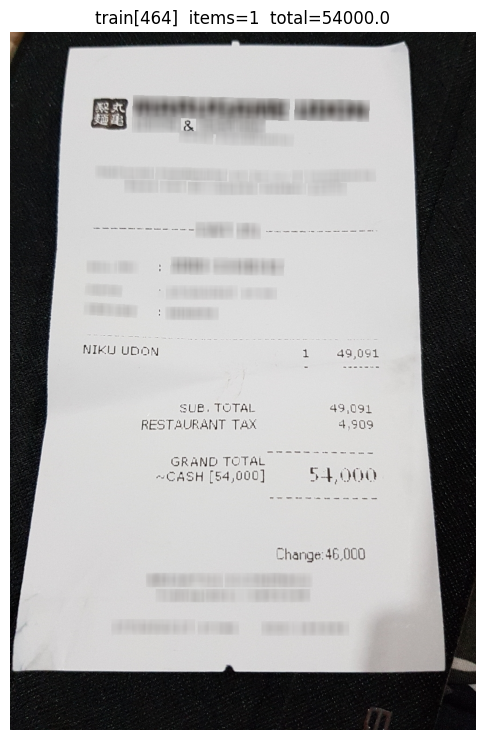

,name,qty,amount
0,NIKU UDON,1.0,49091.0


{
  "store_name": null,
  "date": null,
  "subtotal": 49091.0,
  "tax": 4909.0,
  "total": 54000.0
}

--- train[100]  2/3  size=(2304, 4096) ---


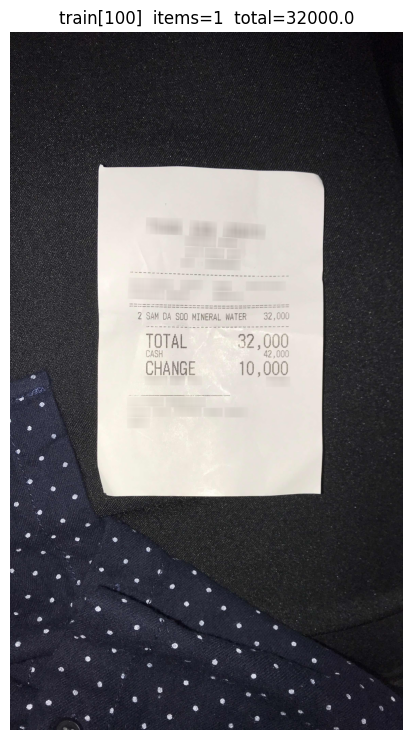

,name,qty,amount
0,SAM DA SOO MINERAL WATER,2.0,32000.0


{
  "store_name": null,
  "date": null,
  "subtotal": null,
  "tax": null,
  "total": 32000.0
}

--- train[496]  3/3  size=(576, 864) ---


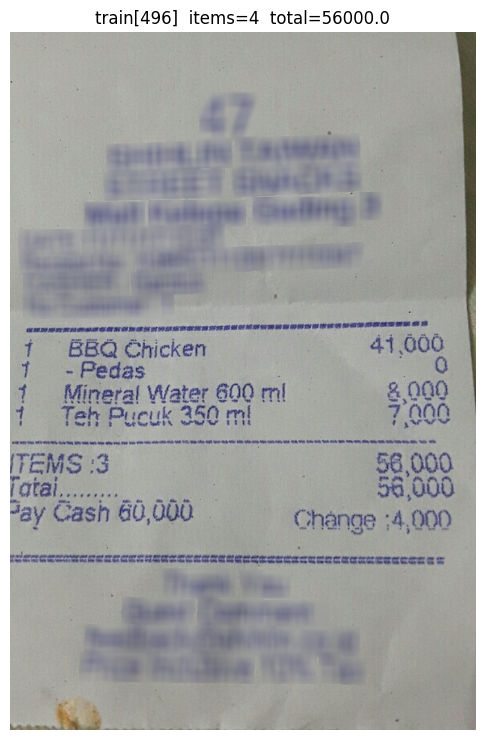

,name,qty,amount
0,BBQ Chicken,1.0,41000.0
1,- Pedas,1.0,0.0
2,Mineral Water 600 ml,1.0,8000.0
3,Teh Pucuk 350 ml,1.0,7000.0


{
  "store_name": null,
  "date": null,
  "subtotal": 56000.0,
  "tax": null,
  "total": 56000.0
}


In [16]:
import random


PREVIEW_N = int(os.environ.get("PREVIEW_N", "3"))


def show_random_train_samples(n=PREVIEW_N, seed=None):
    cord_dataset = globals().get("dataset")
    if cord_dataset is None:
        print("CORD not loaded — run the split cell first")
        return
    split = cord_dataset["train"]
    n = min(n, len(split))
    rng = random.Random(seed)
    idxs = rng.sample(range(len(split)), n)
    print(f"showing {n} of {len(split)} official train receipts  ids={idxs}")
    for rank, idx in enumerate(idxs, 1):
        row = split[idx]
        gold = cord_to_schema(ground_truth_of(row))
        image = row["image"]
        if hasattr(image, "convert"):
            image = image.convert("RGB")
        print(f"\n--- train[{idx}]  {rank}/{n}  size={getattr(image, 'size', None)} ---")
        if plt is not None:
            fig, ax = plt.subplots(figsize=(5.5, 7.5))
            ax.imshow(image)
            ax.set_title(f"train[{idx}]  items={len(gold['line_items'])}  total={gold.get('total')}")
            ax.axis("off")
            fig.tight_layout()
            plt.show()
        else:
            display(image)
        items = gold.get("line_items") or []
        if pd is not None and items:
            _show_df(pd.DataFrame(items), None)
        header = {k: gold.get(k) for k in ("store_name", "date", "subtotal", "tax", "total")}
        print(json.dumps(header, indent=2))
        if not items:
            print(json.dumps(gold, indent=2))


show_random_train_samples()


In [17]:
# Repeated non-finite fp16 gradients appeared early in the last T4 run.
# Set TRAIN_LR_OVERRIDE to explicitly select another rate.
if os.environ.get("TRAIN_LR") in (None, "1e-5", "1e-6"):
    os.environ["TRAIN_LR"] = os.environ.get("TRAIN_LR_OVERRIDE", "1e-7")
print("training learning rate", os.environ["TRAIN_LR"])


training learning rate 1e-7


In [ ]:
def wandb_init(extra=None):
    if os.environ.get("WANDB_MODE") == "disabled" or not os.environ.get("WANDB_API_KEY"):
        print("wandb disabled")
        return None
    try:
        import wandb

        cfg = {
            "model_id": MODEL_ID,
            "lora_r": LORA_R,
            "lora_alpha": LORA_ALPHA,
            "lora_dropout": LORA_DROPOUT,
            "bits": 4,
            "image_resolution": LONG_EDGE,
            "learning_rate": float(os.environ.get("TRAIN_LR", "1e-5")),
            "train_size": len(splits.get("train", [])),
            "val_size": len(splits.get("validation", [])),
            "split_hash": {k: split_hash(v) for k, v in splits.items() if v},
        }
        if extra:
            cfg.update(extra)
        return wandb.init(project=os.environ.get("WANDB_PROJECT", "vlm-receipt-extraction"), config=cfg)
    except Exception as exc:
        print("wandb skipped", exc)
        return None


wb = wandb_init()


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: maheshnallada to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


## 6c. Optional SROIE header data

SROIE supplies labeled company/date fields that CORD does not. Keep these rows separate from CORD line-item training or train them with a header-specific prompt and masked loss.

This section loads `darentang/sroie`, extracts entities.company and entities.date, and retains OCR words and pixel bounding boxes, and prepares header-only chat rows. It does not mix unlabeled line-item fields into the CORD target.


#### Helpers: `normalize_sroie_date`, `sroie_to_header`, `_sroie_text`


In [ ]:
import json
import os
import random
from datetime import datetime
from pathlib import Path


SROIE_DATASET_ID = os.environ.get("SROIE_DATASET_ID", "jsdnrs/ICDAR2019-SROIE")
SROIE_ADAPTER_DIR = Path(os.environ.get("SROIE_ADAPTER_DIR", "outputs/lora-sroie-header"))
SROIE_HEADER_PROMPT = (
    "Extract only the receipt company and date as JSON with keys store_name and date (YYYY-MM-DD). "
    "Copy visible text only. Use null when a field is absent or uncertain. Do not copy product names into store_name."
 )


def normalize_sroie_date(value):
    if not isinstance(value, str) or not value.strip():
        return None
    text = value.strip()
    for date_format in ("%Y-%m-%d", "%Y/%m/%d", "%Y%m%d", "%d/%m/%Y", "%d-%m-%Y", "%m/%d/%Y"):
        try:
            return datetime.strptime(text, date_format).date().isoformat()
        except ValueError:
            continue
    return None


def sroie_to_header(row):
    entities = row.get("entities") or {}
    return {
        "store_name": entities.get("company") or None,
        "date": normalize_sroie_date(entities.get("date")),
    }


def _sroie_text(row):
    words = row.get("words") or []
    return " ".join(
        str(word.get("text", "") if isinstance(word, dict) else word)
        for word in words
    )


#### Helpers: `_sroie_examples`


In [19]:
def _sroie_examples(split_name):
    if sroie is None or split_name not in sroie:
        return []
    examples = []
    for index, row in enumerate(sroie[split_name]):
        examples.append(
            {
                "id": str(row.get("id", f"{split_name}-{index}")),
                "image": row["image"],
                "target": sroie_to_header(row),
                "text": _sroie_text(row),
            }
        )
    return examples


sroie = None
sroie_header_rows = []
sroie_train_rows = []
sroie_validation_rows = []
sroie_eval_rows = []
try:
    from datasets import load_dataset

    sroie = load_dataset(SROIE_DATASET_ID)
    sroie_header_rows = _sroie_examples("train")
    train_indices = list(range(len(sroie_header_rows)))
    random.Random(3407).shuffle(train_indices)
    validation_count = max(1, round(len(train_indices) * 0.1)) if len(train_indices) > 1 else 0
    validation_indices = set(train_indices[:validation_count])
    sroie_train_rows = [
        row for index, row in enumerate(sroie_header_rows) if index not in validation_indices
    ]
    sroie_validation_rows = [
        row for index, row in enumerate(sroie_header_rows) if index in validation_indices
    ]
    sroie_eval_rows = _sroie_examples("test")
    print(
        "SROIE loaded", SROIE_DATASET_ID,
        "train", len(sroie_train_rows),
        "validation", len(sroie_validation_rows),
        "held-out test", len(sroie_eval_rows),
    )
    if not sroie_eval_rows:
        print("SROIE has no official test split; held-out header evaluation is disabled")
except Exception as exc:
    sroie = None
    print("SROIE skipped; install datasets or set SROIE_DATASET_ID:", exc)


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/319M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/191M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/626 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/361 [00:00<?, ? examples/s]

SROIE loaded jsdnrs/ICDAR2019-SROIE train 563 validation 63 held-out test 361


## 7. VLM load + one-page infer (needs GPU)

Skip on CPU. Temperature 0. One repair generation if JSON/schema fails.


In [29]:
vlm = {"model": None, "processor": None}


def load_vlm(adapter_path=None):
    if not HAS_GPU:
        print("no GPU — skip VLM load")
        return
    from transformers import AutoProcessor, BitsAndBytesConfig, Qwen2_5_VLForConditionalGeneration

    base = HF_BASE_ID
    processor = AutoProcessor.from_pretrained(base, min_pixels=EVAL_MIN_PIXELS, max_pixels=MAX_PIXELS)
    quant = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16)
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        base, quantization_config=quant, device_map="auto", torch_dtype=torch.float16
    )
    if adapter_path and Path(adapter_path).exists():
        from peft import PeftModel

        model = PeftModel.from_pretrained(model, adapter_path)
    model.eval()
    # Qwen generation_config still carries temperature; greedy decode warns otherwise.
    if getattr(model, "generation_config", None) is not None:
        model.generation_config.temperature = None
        model.generation_config.top_p = None
        model.generation_config.top_k = None
    vlm["model"], vlm["processor"] = model, processor
    print("loaded", base, "adapter", adapter_path or "base")


def free_vlm():
    import gc

    vlm["model"] = None
    vlm["processor"] = None
    gc.collect()
    if HAS_GPU and torch is not None:
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass
        torch.cuda.reset_peak_memory_stats()
    print("freed eval VLM (required before QLoRA — T4 cannot hold two 3B copies)")


def infer_page(image, repair_hint=None):
    if vlm["model"] is None:
        raise RuntimeError("model not loaded")
    image = resize_image(image, EVAL_MIN_PIXELS, MAX_PIXELS)
    prompt = EXTRACT_PROMPT if not repair_hint else f"Previous output failed: {repair_hint}\n{EXTRACT_PROMPT}"
    messages = [{"role": "user", "content": [{"type": "image", "image": image}, {"type": "text", "text": prompt}]}]
    text = vlm["processor"].apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = vlm["processor"](text=[text], images=[image], padding=True, return_tensors="pt")
    inputs = inputs.to(vlm["model"].device)
    out = vlm["model"].generate(**inputs, max_new_tokens=1024, do_sample=False)
    trimmed = out[:, inputs["input_ids"].shape[1] :]
    return vlm["processor"].batch_decode(trimmed, skip_special_tokens=True)[0]


def extract_image(image, page_text=""):
    raw = infer_page(image)
    print("RAW OUTPUT From model", raw)
    repair = None
    try:
        parse_model_output(raw)
    except ValueError as exc:
        repair = infer_page(image, repair_hint=str(exc))
    result, before, _ = run_pipeline([{"raw": raw, "repair": repair, "text": page_text}])
    return result, raw, before[0]


if HAS_GPU:
    load_vlm()
else:
    print("CPU: VLM cells below will no-op")


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

loaded Qwen/Qwen2.5-VL-3B-Instruct adapter base


## 8. Zero-shot eval on a frozen test slice

Same ids will be reused after fine-tuning. `EVAL_N` defaults to 8 on a T4. After this cell, `free_vlm()` must run so QLoRA can load.

CORD gold `store_name` / `date` are always null. F1 0 with high Exact means the model also emitted null (or grounding wiped a guess).


#### Helpers: `cord_page_text`, `_receipt_names_difference`, `_non_null_count`


In [ ]:
def cord_page_text(row):
    raw = row["ground_truth"]
    payload = json.loads(raw) if isinstance(raw, str) else raw
    lines = []
    for line in payload.get("valid_line") or []:
        words = [w.get("text", "") for w in line.get("words") or []]
        if words:
            lines.append(" ".join(words))
    return "\n".join(lines)


raw_eval_outputs = {}
raw_eval_ids = {}


def _receipt_names_difference(gold_items, predicted_items):
    remaining = list(predicted_items)
    missing = []
    for gold_item in gold_items:
        match_index = next(
            (
                index
                for index, candidate in enumerate(remaining)
                if names_match(candidate.get("name") or "", gold_item.get("name") or "")
            ),
            None,
        )
        if match_index is None:
            missing.append(gold_item.get("name"))
        else:
            remaining.pop(match_index)
    return missing, [item.get("name") for item in remaining]


def _non_null_count(receipt):
    values = [receipt.get(key) for key in ("store_name", "date", "subtotal", "tax", "total")]
    for item in receipt.get("line_items") or []:
        values.extend(item.get(key) for key in ("name", "qty", "unit_price", "amount"))
    return sum(value is not None for value in values)


#### Helpers: `_receipt_diagnostics`, `_grounding_metric_view`


In [ ]:
def _receipt_diagnostics(golds, before_preds, after_preds, ids):
    rows = []
    for gold, before, after, receipt_id in zip(golds, before_preds, after_preds, ids, strict=True):
        missing_before, extra_before = _receipt_names_difference(
            gold.get("line_items") or [], before.get("line_items") or []
        )
        missing_after, extra_after = _receipt_names_difference(
            gold.get("line_items") or [], after.get("line_items") or []
        )
        rows.append({
            "receipt_id": receipt_id,
            "gold_items": len(gold.get("line_items") or []),
            "before_items": len(before.get("line_items") or []),
            "after_items": len(after.get("line_items") or []),
            "missing_names_before": missing_before,
            "missing_names_after": missing_after,
            "extra_names_before": extra_before,
            "extra_names_after": extra_after,
            "fields_removed_by_grounding": max(0, _non_null_count(before) - _non_null_count(after)),
            "exact_before": exact_receipt(gold, before),
            "exact_after": exact_receipt(gold, after),
        })
    return rows


def _grounding_metric_view(summary):
    return {
        "fields": summary["fields"],
        "exact_match_receipt": summary["exact_match_receipt"],
        "hallucination_rate": summary["hallucination_after_grounding"],
    }


#### Helpers: `compare_raw_outputs`


In [30]:
def compare_raw_outputs():
    base = raw_eval_outputs.get("zero-shot")
    tuned = raw_eval_outputs.get("fine-tuned")
    if not base or not tuned:
        print("raw comparison unavailable: run both evaluation stages")
        return 0
    if raw_eval_ids.get("zero-shot") != raw_eval_ids.get("fine-tuned"):
        print("raw comparison invalid: stages used different receipt ids")
        return 0
    changed = sum(left != right for left, right in zip(base, tuned, strict=True))
    print(f"raw generations changed for {changed}/{len(base)} identical evaluation receipts")
    if changed == 0:
        print("WARNING: adapter produced no output changes on this slice; do not tune further until loading/training is checked.")
    return changed


In [ ]:
def hallucination_rate(preds, texts, *, after_grounding=True):
    del after_grounding
    missing = non_null = 0
    for pred, text in zip(preds, texts, strict=True):
        verification = pred.get("_verification") or {}
        for field in ("store_name", "date", "subtotal", "tax", "total"):
            value = pred.get(field)
            if value is None or verification.get(field) == "derived":
                continue
            non_null += 1
            if isinstance(value, str) and not text_present(value, text):
                missing += 1
            elif isinstance(value, (int, float)) and not numbers_match(float(value), text):
                missing += 1
        for index, item in enumerate(pred.get("line_items") or []):
            for field in ("name", "qty", "unit_price", "amount"):
                value = item.get(field)
                path = f"line_items.{index}.{field}"
                if value is None or verification.get(path) == "derived":
                    continue
                non_null += 1
                if isinstance(value, str) and not text_present(value, text):
                    missing += 1
                elif isinstance(value, (int, float)) and not numbers_match(float(value), text):
                    missing += 1
    return 0.0 if not non_null else missing / non_null


#### Helpers: `cord_eval_rows`


In [ ]:
from contextlib import redirect_stdout
from io import StringIO


def cord_eval_rows(n=None):
    if n is None:
        n = EVAL_N
    if dataset is None:
        return []
    rows = []
    for index, row in enumerate(dataset["test"]):
        raw = row["ground_truth"]
        payload = json.loads(raw) if isinstance(raw, str) else raw
        ground_truth = payload["gt_parse"]
        image_id = str((payload.get("meta") or {}).get("image_id", f"test-{index}"))
        actual = cord_page_text(row)
        rows.append({
            "id": image_id,
            "image": row["image"],
            "actual": actual,
            "text": actual,
            "ground_truth": ground_truth,
            "gold": cord_to_schema(ground_truth),
        })
        if len(rows) >= n:
            break
    return rows


evaluation_details = {}


#### Helpers: `eval_vlm`


In [32]:
def eval_vlm(rows, stage):
    golds, preds, before_preds, texts, latencies, receipt_ids = [], [], [], [], [], []
    raw_outputs = []
    details = []
    if vlm["model"] is None:
        print("no model — skip", stage)
        return None
    if HAS_GPU:
        torch.cuda.reset_peak_memory_stats()
    for index, row in enumerate(rows):
        started = time.perf_counter()
        with redirect_stdout(StringIO()):
            result, raw, before = extract_image(row["image"], row.get("text") or "")
        latencies.append((time.perf_counter() - started) * 1000.0)
        keys = ("store_name", "date", "line_items", "subtotal", "tax", "total")
        pred = {key: result[key] for key in keys}
        before_pred = {key: before.get(key) for key in keys}
        gold = row["gold"]
        receipt_id = str(row.get("id", index))
        golds.append(gold)
        preds.append({**pred, "_verification": result.get("_verification", {})})
        before_preds.append(before_pred)
        texts.append(row.get("text") or "")
        receipt_ids.append(receipt_id)
        raw_outputs.append(raw)
        details.append({
            "stage": stage,
            "receipt_id": receipt_id,
            "actual": row.get("actual", row.get("text", "")),
            "ground_truth": gold,
            "raw_predicted": raw,
            "pred": pred,
        })
        print(f"{stage} {index + 1}/{len(rows)} receipt={receipt_id}")

    raw_eval_outputs[stage] = raw_outputs
    raw_eval_ids[stage] = receipt_ids
    evaluation_details[stage] = details
    summary = summarize(golds, preds, texts, latencies, stage)
    before_summary = summarize(golds, before_preds, texts, latencies, f"{stage}-before-grounding")
    summary["pre_grounding"] = _grounding_metric_view(before_summary)
    summary["post_grounding"] = _grounding_metric_view(summary)
    print(
        f"{stage} pre-grounding: receipt_exact={before_summary['exact_match_receipt']:.3f} "
        f"hallucination={before_summary['hallucination_after_grounding']:.3f}"
    )
    print(
        f"{stage} post-grounding: receipt_exact={summary['exact_match_receipt']:.3f} "
        f"hallucination={summary['hallucination_after_grounding']:.3f}"
    )
    diagnostic_rows = _receipt_diagnostics(golds, before_preds, preds, receipt_ids)
    diagnostic_frame = pd.DataFrame(diagnostic_rows) if pd is not None else diagnostic_rows
    diagnostic_frame.to_csv(f"{stage}_diagnostic.csv", index=False)
    _show_df(diagnostic_frame, f"{stage} receipt-level grounding diagnostics")
    show_table(summary)
    result_columns = ["stage", "receipt_id", "actual", "ground_truth", "raw_predicted", "pred"]
    result_frame = pd.DataFrame(details, columns=result_columns) if pd is not None else details
    result_frame.to_csv(f"{stage}_results.csv", index=False)
    _show_df(result_frame, f"{stage} results: actual, ground truth, raw prediction, final prediction")
    return summary


print("evaluation DataFrame output ready")


evaluation DataFrame output ready


eval rows 32 requested 32
zero-shot 1/32 receipt=0
zero-shot 2/32 receipt=1
zero-shot 3/32 receipt=2
zero-shot 4/32 receipt=3
zero-shot 5/32 receipt=4
zero-shot 6/32 receipt=5
zero-shot 7/32 receipt=6
zero-shot 8/32 receipt=7
zero-shot 9/32 receipt=8
zero-shot 10/32 receipt=9
zero-shot 11/32 receipt=10
zero-shot 12/32 receipt=11
zero-shot 13/32 receipt=12
zero-shot 14/32 receipt=13
zero-shot 15/32 receipt=14
zero-shot 16/32 receipt=15
zero-shot 17/32 receipt=16
zero-shot 18/32 receipt=17
zero-shot 19/32 receipt=18
zero-shot 20/32 receipt=19
zero-shot 21/32 receipt=20
zero-shot 22/32 receipt=21
zero-shot 23/32 receipt=22
zero-shot 24/32 receipt=23
zero-shot 25/32 receipt=24
zero-shot 26/32 receipt=25
zero-shot 27/32 receipt=26
zero-shot 28/32 receipt=27
zero-shot 29/32 receipt=28
zero-shot 30/32 receipt=29
zero-shot 31/32 receipt=30
zero-shot 32/32 receipt=31
zero-shot pre-grounding: receipt_exact=0.188 hallucination=0.144
zero-shot post-grounding: receipt_exact=0.188 hallucination=0.00

,receipt_id,gold_items,before_items,after_items,missing_names_before,missing_names_after,extra_names_before,extra_names_after,fields_removed_by_grounding,exact_before,exact_after
0,0,1,1,1,[],[],[],[],3,False,False
1,1,3,2,2,[J.STB PROMO],[J.STB PROMO],[],[],3,False,False
2,2,2,2,2,[],[],[],[],2,False,False
3,3,1,1,1,[],[],[],[],2,True,True
4,4,3,0,0,"[ICE BLACKCOFFE, AVOCADO COFFEE, CHIKEN KATSU FF]","[ICE BLACKCOFFE, AVOCADO COFFEE, CHIKEN KATSU FF]",[],[],0,False,False
5,5,1,1,1,[TRAD KY TOAST CARTE],[TRAD KY TOAST CARTE],[ITEMS 1.00],[ITEMS 1.00],0,False,False
6,6,3,3,2,[],[CHOCO CUS ARD PASTRY],[],[],4,False,False
7,7,2,1,1,[Kupon 15],[Kupon 15],[],[],0,False,False
8,8,3,3,2,[],[[REG] BLACK SAKURA],[],[],4,False,False
9,9,1,1,0,[],[Bumbu Kaldu Ayam 1],[],[],4,False,False


zero-shot  n=32  receipt_exact=0.188  hallu=0.000  latency_ms p50/p95=23670.27419499982/47361.569829000015  gpu=3.01 GiB


,field,precision,recall,f1,exact_match,labeled,ignored_unlabeled
0,store_name,0.000,0.000,0.000,0.000,0,32
1,date,0.000,0.000,0.000,0.000,0,32
2,subtotal,0.778,0.667,0.718,0.667,21,11
3,tax,0.636,0.500,0.560,0.500,14,18
4,total,0.667,0.581,0.621,0.581,31,1
5,line_items.name,0.843,0.702,0.766,0.663,89,0
6,line_items.qty,0.935,0.795,0.859,0.753,77,12
7,line_items.unit_price,0.429,0.375,0.400,0.300,20,69
8,line_items.amount,0.714,0.556,0.625,0.523,86,3


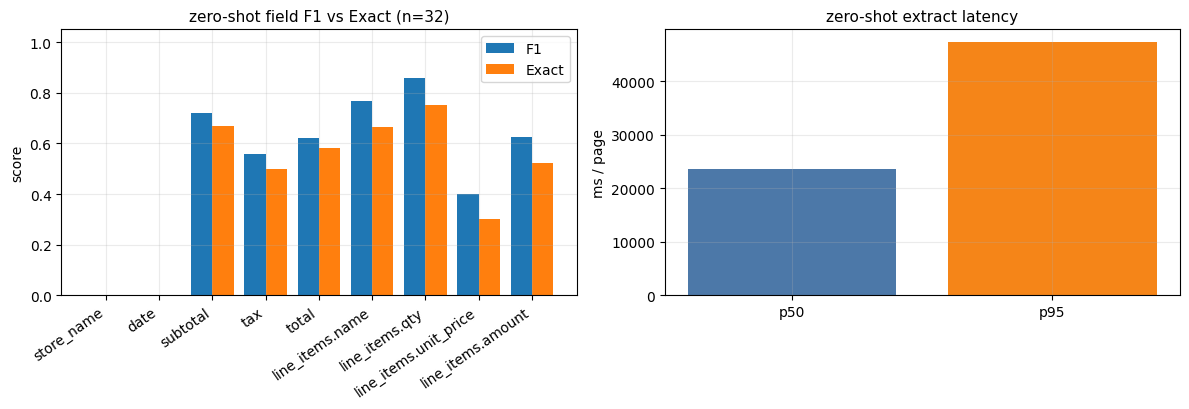

zero-shot results: actual, ground truth, raw prediction, final prediction


,stage,receipt_id,actual,ground_truth,raw_predicted,pred
0,zero-shot,0,901016\n-TICKET CP\n2\n60.000\n60.000\nTOTAL D...,"{'line_items': [{'name': '-TICKET CP', 'qty': ...","```json\n{\n ""store_name"": ""B. B"",\n ""date"":...","{'store_name': None, 'date': None, 'line_items..."
1,zero-shot,1,J.STB PROMO\n17500\nY.B.BAT\n46000\nY.BASO PRO...,"{'line_items': [{'name': 'J.STB PROMO', 'amoun...","```json\n{\n ""store_name"": ""J.STB PROMO"",\n...","{'store_name': 'J.STB PROMO', 'date': None, 'l..."
2,zero-shot,2,"1\nJASMINE MT ( L )\n24,000\nCOCONUT JELLY ( L...","{'line_items': [{'name': 'JASMINE MT ( L )', '...","```json\n{\n ""store_name"": ""BINTANG"",\n ...","{'store_name': None, 'date': None, 'line_items..."
3,zero-shot,3,"1X\n@11000\nDONAT GULA\n11,000\n1.00xITEMs\nSU...","{'line_items': [{'name': 'DONAT GULA', 'qty': ...","```json\n{\n ""store_name"": ""Dynamic Natural...","{'store_name': None, 'date': None, 'line_items..."
4,zero-shot,4,"ICE BLACKCOFFE\n2\n82,000\nAVOCADO COFFEE\n1\n...","{'line_items': [{'name': 'ICE BLACKCOFFE', 'qt...",!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!...,"{'store_name': None, 'date': None, 'line_items..."
5,zero-shot,5,TRAD KY TOAST CARTE\n28.182\nITEMS 1.00\nSUBTT...,{'line_items': [{'name': 'TRAD KY TOAST CARTE'...,"```json\n{\n ""store_name"": ""TRAD KY TOAST CAR...","{'store_name': 'TRAD KY TOAST CARTE', 'date': ..."
6,zero-shot,6,"1\nEGG TART\n13,000\n2\nCHOCO CUS ARD PASTRY\n...","{'line_items': [{'name': 'EGG TART', 'qty': 1....","```json\n{\n ""store_name"": null,\n ""date"": n...","{'store_name': None, 'date': None, 'line_items..."
7,zero-shot,7,"Kupon 15\n100,000\nADD CHICKEN BOX\n909\nSubto...","{'line_items': [{'name': 'Kupon 15', 'amount':...","```json\n{\n ""store_name"": ""Kupon 15"",\n ""da...","{'store_name': 'Kupon 15', 'date': None, 'line..."
8,zero-shot,8,"1\n[REG] BLACK SAKURA\n45,455\n1\nCOOKIE DOH S...","{'line_items': [{'name': '[REG] BLACK SAKURA',...","```json\n{\n ""store_name"": null,\n ""date"": n...","{'store_name': None, 'date': None, 'line_items..."
9,zero-shot,9,Bumbu Kaldu Ayam 1\n36000\n36000\nSub Total 36...,"{'line_items': [{'name': 'Bumbu Kaldu Ayam 1',...","```json\n{\n ""store_name"": null,\n ""date"": n...","{'store_name': None, 'date': None, 'line_items..."


freed eval VLM (required before QLoRA — T4 cannot hold two 3B copies)


In [33]:
EVAL_N = 32
eval_rows = cord_eval_rows(EVAL_N)
print("eval rows", len(eval_rows), "requested", EVAL_N)
if len(eval_rows) < EVAL_N:
    print("WARNING: CORD test split is smaller than the requested evaluation slice")
zero_shot = eval_vlm(eval_rows, "zero-shot") if eval_rows and HAS_GPU else None
if HAS_GPU:
    free_vlm()


## 9. QLoRA fine-tune (needs GPU)

Language / attention / MLP by default. Set `TRAIN_VISION_LAYERS=1` to try vision-layer LoRA when the GPU has enough memory.

**Truncation vs OOM:** cutting `max_length` while leaving full-resolution CORD images
makes Unsloth tokenize ~1000 image tokens + prompt + JSON, then the trainer truncates
the *tail*. That tail is the assistant JSON (labels become `-100` / empty → NaN) or
the image placeholders (Unsloth: image-token mismatch). Do **not** jump to 8192 either:
attention memory is O(seq²) and a second 3B still on GPU OOMs the T4.

This cell shrinks **training images** to `TRAIN_VISION_TOKENS` (default 768), keeps
`TRAIN_MAX_SEQ=3072` for long receipts, sets that length on the model + collator +
`SFTConfig`, and drops leftovers that still do not fit. `MAX_TRAIN=0` uses the full official train split; override it for a smaller smoke run. `TRAIN_EPOCHS=2` is the default.

If loss drops then becomes **NaN**, one fp16 overflow poisoned Adam. The train cell skips non-finite gradients, uses the conservative `1e-5` default, and restores the last finite checkpoint.



In [34]:
def report_cord_unit_price_coverage(split_name):
    cord_dataset = globals().get("dataset")
    if cord_dataset is None:
        print("CORD not loaded; unit-price coverage unavailable")
        return
    item_count = 0
    labeled_count = 0
    for row in cord_dataset[split_name]:
        for item in flatten_menu_items(ground_truth_of(row).get("menu")):
            item_count += 1
            if parse_money(item.get("unitprice")) is not None:
                labeled_count += 1
    coverage = labeled_count / item_count if item_count else 0.0
    print(
        f"{split_name}: CORD unit_price labels={labeled_count}/{item_count} "
        f"({coverage:.1%}); unlabeled unit prices are not trainable targets"
    )


report_cord_unit_price_coverage("train")
report_cord_unit_price_coverage("validation")


train: CORD unit_price labels=631/2426 (26.0%); unlabeled unit prices are not trainable targets
validation: CORD unit_price labels=50/271 (18.5%); unlabeled unit prices are not trainable targets


#### Helpers: `compact_target`, `to_messages`


In [ ]:
MAX_TRAIN = int(os.environ.get("MAX_TRAIN", "200"))  # 0 = full official train split
TRAIN_EPOCHS = int(os.environ.get("TRAIN_EPOCHS", "1"))
EVAL_STEPS = int(os.environ.get("EVAL_STEPS", "25"))
EARLY_STOPPING_PATIENCE = int(os.environ.get("EARLY_STOPPING_PATIENCE", "2"))
TRAIN_VISION_LAYERS = os.environ.get("TRAIN_VISION_LAYERS", "0") == "1"
CHAT_OVERHEAD = 48  # Qwen chat template / specials, not counting vision tokens


def compact_target(target):
    return json.dumps(target, ensure_ascii=False, separators=(",", ":"))


def to_messages(image, target):
    return [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": EXTRACT_PROMPT},
            ],
        },
        {"role": "assistant", "content": [{"type": "text", "text": compact_target(target)}]},
    ]


#### Helpers: `convert_split`, `estimate_seq_len`


In [ ]:
def convert_split(split, limit=0):
    rows = []
    vis_counts = []
    json_chars = []
    for row in split:
        image = resize_image(row["image"], TRAIN_MIN_PIXELS, TRAIN_MAX_PIXELS)
        target = cord_to_schema(ground_truth_of(row))
        payload = compact_target(target)
        vis_counts.append(vision_token_count(image))
        json_chars.append(len(payload))
        rows.append({"messages": to_messages(image, target)})
        if limit and len(rows) >= limit:
            break
    if vis_counts:
        stats = pd.DataFrame({
            "vision_tokens": vis_counts,
            "json_chars": json_chars,
        }) if pd is not None else None
        if stats is not None:
            _show_df(stats.describe(percentiles=[0.5, 0.95]).T.round(1), f"resized train images n={len(rows)}")
        if plt is not None:
            _style_plot()
            fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
            axes[0].hist(vis_counts, bins=min(20, max(5, len(vis_counts) // 8)), color="#4C78A8")
            axes[0].axvline(TRAIN_VISION_TOKENS, color="#E45756", linestyle="--", label="TRAIN_VISION_TOKENS")
            axes[0].set_title("Training vision tokens")
            axes[0].set_xlabel("tokens")
            axes[0].legend()
            axes[1].hist(json_chars, bins=min(20, max(5, len(json_chars) // 8)), color="#54A24B")
            axes[1].set_title("Compact JSON size")
            axes[1].set_xlabel("characters")
            fig.tight_layout()
            plt.show()
        else:
            print(
                "resized train images: n", len(rows),
                "vision tokens p50/max", sorted(vis_counts)[len(vis_counts) // 2], max(vis_counts),
                "json chars p50/max", sorted(json_chars)[len(json_chars) // 2], max(json_chars),
            )
    return rows


def estimate_seq_len(tokenizer, row):
    image = row["messages"][0]["content"][0]["image"]
    completion = row["messages"][1]["content"][0]["text"]
    text_ids = tokenizer(EXTRACT_PROMPT + completion, add_special_tokens=False)["input_ids"]
    return vision_token_count(image) + len(text_ids) + CHAT_OVERHEAD


#### Helpers: `filter_to_budget`, `plot_train_loss`


In [ ]:
def filter_to_budget(tokenizer, rows, max_seq):
    kept, dropped, lengths = [], 0, []
    for row in rows:
        n = estimate_seq_len(tokenizer, row)
        lengths.append(n)
        if n <= max_seq:
            kept.append(row)
        else:
            dropped += 1
    if lengths:
        ordered = sorted(lengths)
        summary = {
            "max_seq": max_seq,
            "p50": ordered[len(ordered) // 2],
            "p95": ordered[int(len(ordered) * 0.95)],
            "max": ordered[-1],
            "kept": len(kept),
            "dropped": dropped,
        }
        _show_df(pd.DataFrame([summary]) if pd is not None else summary, "token budget")
        if plt is not None:
            _style_plot()
            fig, ax = plt.subplots(figsize=(10, 3.4))
            ax.hist(lengths, bins=min(24, max(6, len(lengths) // 8)), color="#4C78A8")
            ax.axvline(max_seq, color="#E45756", linestyle="--", label=f"TRAIN_MAX_SEQ={max_seq}")
            ax.set_title("Estimated sequence length vs budget")
            ax.set_xlabel("tokens (vision + prompt + JSON + chat)")
            ax.legend()
            fig.tight_layout()
            plt.show()
    if not kept:
        raise RuntimeError(
            "every training row exceeds TRAIN_MAX_SEQ; lower TRAIN_VISION_TOKENS "
            "or raise TRAIN_MAX_SEQ (T4 safe ceiling is about 4096 after free_vlm)"
        )
    return kept


def plot_train_loss(trainer):
    logs = [row for row in getattr(getattr(trainer, "state", None), "log_history", []) or [] if "loss" in row]
    if not logs:
        return
    if pd is not None:
        df = pd.DataFrame(logs)
        cols = [c for c in ("step", "loss", "learning_rate") if c in df.columns]
        _show_df(df[cols].round(4), "training log")
    if plt is None:
        return
    _style_plot()
    steps = [row.get("step", i + 1) for i, row in enumerate(logs)]
    losses = [row["loss"] for row in logs]
    fig, ax = plt.subplots(figsize=(10, 3.6))
    ax.plot(steps, losses, marker="o", markersize=3)
    ax.set_title("QLoRA training loss")
    ax.set_xlabel("step")
    ax.set_ylabel("loss")
    fig.tight_layout()
    plt.show()


#### Helpers: `_sft_length_kwargs`, `_sft_evaluation_kwargs`, `_early_stopping_callback`, `_warmup_steps`


In [ ]:
def _sft_length_kwargs(max_seq):
    import inspect
    from trl import SFTConfig

    params = inspect.signature(SFTConfig.__init__).parameters
    kwargs = {}
    if "max_length" in params:
        kwargs["max_length"] = max_seq
    if "max_seq_length" in params:
        kwargs["max_seq_length"] = max_seq
    return kwargs


def _sft_evaluation_kwargs(has_eval):
    if not has_eval:
        return {}
    import inspect
    from trl import SFTConfig

    params = inspect.signature(SFTConfig.__init__).parameters
    kwargs = {
        "eval_steps": EVAL_STEPS,
        "load_best_model_at_end": True,
        "metric_for_best_model": "eval_loss",
        "greater_is_better": False,
    }
    if "eval_strategy" in params:
        kwargs["eval_strategy"] = "steps"
    elif "evaluation_strategy" in params:
        kwargs["evaluation_strategy"] = "steps"
    return {key: value for key, value in kwargs.items() if key in params}


def _early_stopping_callback(has_eval):
    if not has_eval:
        return None
    from transformers import EarlyStoppingCallback

    return EarlyStoppingCallback(
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        early_stopping_threshold=0.001,
    )


def _warmup_steps(n_rows, accum=8):
    return max(5, int(0.2 * max(1, math.ceil(n_rows / accum))))


#### Helpers: `_nan_callback`, `_save_finite_adapter`


In [ ]:
def _nan_callback():
    from transformers import TrainerCallback

    class GuardNaNCallback(TrainerCallback):
        def __init__(self):
            self.skipped = 0

        def on_pre_optimizer_step(self, args, state, control, model=None, **kwargs):
            if model is None:
                return
            for param in model.parameters():
                if param.grad is not None and not torch.isfinite(param.grad).all():
                    self.skipped += 1
                    print(f"skip step {state.global_step}: non-finite grad (#{self.skipped})")
                    model.zero_grad(set_to_none=True)
                    return

    return GuardNaNCallback()


def _save_finite_adapter(model, processor, trainer, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    logs = [row for row in trainer.state.log_history if "loss" in row]
    last = logs[-1]["loss"] if logs else None
    last_good = 0
    for row in logs:
        if math.isfinite(float(row["loss"])):
            last_good = int(row.get("step", last_good))
    print("last loss", last, "last finite step", last_good)
    if last is not None and not math.isfinite(float(last)):
        ckpts = []
        for path in out_dir.glob("checkpoint-*"):
            try:
                step = int(path.name.split("-")[-1])
            except ValueError:
                continue
            if step <= last_good:
                ckpts.append((step, path))
        if ckpts:
            step, ckpt = max(ckpts)
            print("restoring finite adapter from", ckpt)
            try:
                trainer._load_from_checkpoint(str(ckpt))
            except Exception as exc:
                print("checkpoint reload failed:", exc)
        else:
            print("no finite checkpoint found; saved adapter may be NaN — re-run this cell")
    model.save_pretrained(out_dir)
    processor.save_pretrained(out_dir)


#### Helpers: `_bind_processor_pixels`


In [ ]:
def _bind_processor_pixels(processor, min_pixels, max_pixels):
    # transformers 5.x: min_pixels/max_pixels are read-only properties on
    # Qwen2VLImageProcessor. Setting them raises "_min_pixels has no setter".
    # Training images are already resized; only touch the writable size dict.
    image_processor = getattr(processor, "image_processor", None)
    if image_processor is None:
        return
    size = getattr(image_processor, "size", None)
    if not isinstance(size, dict):
        return
    if "shortest_edge" in size:
        size["shortest_edge"] = min_pixels
    if "longest_edge" in size:
        size["longest_edge"] = max_pixels
    size.pop("min_pixels", None)
    size.pop("max_pixels", None)


#### Helpers: `train_unsloth`


In [ ]:
def train_unsloth(train_rows, eval_rows=None):
    from trl import SFTConfig, SFTTrainer
    from unsloth import FastVisionModel
    from unsloth.trainer import UnslothVisionDataCollator

    model, processor = FastVisionModel.from_pretrained(
        MODEL_ID,
        load_in_4bit=True,
        max_seq_length=TRAIN_MAX_SEQ,
        use_gradient_checkpointing="unsloth",
    )
    _bind_processor_pixels(processor, TRAIN_MIN_PIXELS, TRAIN_MAX_PIXELS)
    tokenizer = getattr(processor, "tokenizer", processor)
    train_rows = filter_to_budget(tokenizer, train_rows, TRAIN_MAX_SEQ)
    eval_rows = filter_to_budget(tokenizer, eval_rows, TRAIN_MAX_SEQ) if eval_rows else None
    model = FastVisionModel.get_peft_model(
        model,
        finetune_vision_layers=TRAIN_VISION_LAYERS,
        finetune_language_layers=True,
        finetune_attention_modules=True,
        finetune_mlp_modules=True,
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        use_gradient_checkpointing="unsloth",
        random_state=3407,
    )
    FastVisionModel.for_training(model)
    report = "wandb" if os.environ.get("WANDB_API_KEY") and os.environ.get("WANDB_MODE") != "disabled" else "none"
    collator = UnslothVisionDataCollator(
        model,
        processor,
        max_seq_length=TRAIN_MAX_SEQ,
        resize="max",
        completion_only_loss=True,
    )
    trainer = SFTTrainer(
        model=model,
        tokenizer=processor,
        data_collator=collator,
        train_dataset=train_rows,
        args=SFTConfig(
            per_device_train_batch_size=1,
            gradient_accumulation_steps=8,
            num_train_epochs=TRAIN_EPOCHS,
            learning_rate=float(os.environ.get("TRAIN_LR", "1e-5")),
            warmup_steps=_warmup_steps(len(train_rows)),
            max_grad_norm=1.0,
            logging_steps=1,
            optim="adamw_torch",
            weight_decay=0.001,
            lr_scheduler_type="cosine",
            seed=3407,
            output_dir=str(ADAPTER_DIR),
            report_to=report,
            remove_unused_columns=False,
            dataset_text_field="",
            dataset_kwargs={"skip_prepare_dataset": True},
            fp16=True,
            bf16=False,
            dataloader_num_workers=0,
            save_strategy="steps",
            save_steps=EVAL_STEPS,
            save_total_limit=4,
            logging_nan_inf_filter=False,
            **_sft_length_kwargs(TRAIN_MAX_SEQ),
            **_sft_evaluation_kwargs(eval_rows is not None),
        ),
        eval_dataset=eval_rows,
        callbacks=[callback for callback in (_nan_callback(), _early_stopping_callback(eval_rows is not None)) if callback is not None],
    )
    trainer.train()
    plot_train_loss(trainer)
    _save_finite_adapter(model, processor, trainer, ADAPTER_DIR)
    del trainer, model
    import gc
    gc.collect()
    if HAS_GPU:
        torch.cuda.empty_cache()
    return ADAPTER_DIR


#### Helpers: `train_hf`


In [ ]:
def train_hf(train_rows, eval_rows=None):
    import gc
    from peft import LoraConfig, get_peft_model
    from transformers import AutoProcessor, BitsAndBytesConfig, Qwen2_5_VLForConditionalGeneration
    from trl import SFTConfig, SFTTrainer

    # A failed Unsloth attempt already imported unsloth (which patches SFTTrainer)
    # and may still hold the 3B on GPU. Free it first.
    gc.collect()
    if HAS_GPU:
        torch.cuda.empty_cache()

    processor = AutoProcessor.from_pretrained(
        HF_BASE_ID, min_pixels=TRAIN_MIN_PIXELS, max_pixels=TRAIN_MAX_PIXELS
    )
    _bind_processor_pixels(processor, TRAIN_MIN_PIXELS, TRAIN_MAX_PIXELS)
    train_rows = filter_to_budget(processor.tokenizer, train_rows, TRAIN_MAX_SEQ)
    eval_rows = filter_to_budget(processor.tokenizer, eval_rows, TRAIN_MAX_SEQ) if eval_rows else None
    quant = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16)
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        HF_BASE_ID, quantization_config=quant, device_map="auto", torch_dtype=torch.float16
    )
    model = get_peft_model(
        model,
        LoraConfig(
            r=LORA_R,
            lora_alpha=LORA_ALPHA,
            lora_dropout=LORA_DROPOUT,
            target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
            bias="none",
            task_type="CAUSAL_LM",
        ),
    )
    report = "wandb" if os.environ.get("WANDB_API_KEY") else "none"
    trainer_kwargs = {"model": model, "train_dataset": train_rows}
    sft_kwargs = dict(
        per_device_train_batch_size=1,
        gradient_accumulation_steps=8,
        num_train_epochs=TRAIN_EPOCHS,
        learning_rate=float(os.environ.get("TRAIN_LR", "1e-5")),
        warmup_steps=_warmup_steps(len(train_rows)),
        max_grad_norm=1.0,
        logging_steps=1,
        output_dir=str(ADAPTER_DIR),
        report_to=report,
        remove_unused_columns=False,
        fp16=True,
        dataloader_num_workers=0,
        dataset_text_field="",
        dataset_kwargs={"skip_prepare_dataset": True},
        save_strategy="steps",
        save_steps=EVAL_STEPS,
        save_total_limit=4,
        logging_nan_inf_filter=False,
    )
    sft_kwargs.update(_sft_length_kwargs(TRAIN_MAX_SEQ))
    sft_kwargs.update(_sft_evaluation_kwargs(eval_rows is not None))
    try:
        from unsloth.trainer import UnslothVisionDataCollator

        trainer_kwargs["tokenizer"] = processor
        trainer_kwargs["data_collator"] = UnslothVisionDataCollator(
            model, processor, max_seq_length=TRAIN_MAX_SEQ, resize="max", completion_only_loss=True
        )
    except Exception:
        trainer_kwargs["processing_class"] = processor
    if eval_rows is not None:
        trainer_kwargs["eval_dataset"] = eval_rows
    trainer = SFTTrainer(
        args=SFTConfig(**sft_kwargs),
        callbacks=[callback for callback in (_nan_callback(), _early_stopping_callback(eval_rows is not None)) if callback is not None],
        **trainer_kwargs,
    )
    trainer.train()
    plot_train_loss(trainer)
    _save_finite_adapter(model, processor, trainer, ADAPTER_DIR)
    del trainer, model
    import gc
    gc.collect()
    if HAS_GPU:
        torch.cuda.empty_cache()
    return ADAPTER_DIR


#### Configuration and Execution


resized train images n=200


,count,mean,std,min,50%,95%,max
vision_tokens,200.0,696.3,75.7,210.0,720.0,768.0,768.0
json_chars,200.0,202.7,154.8,52.0,150.0,432.1,1210.0


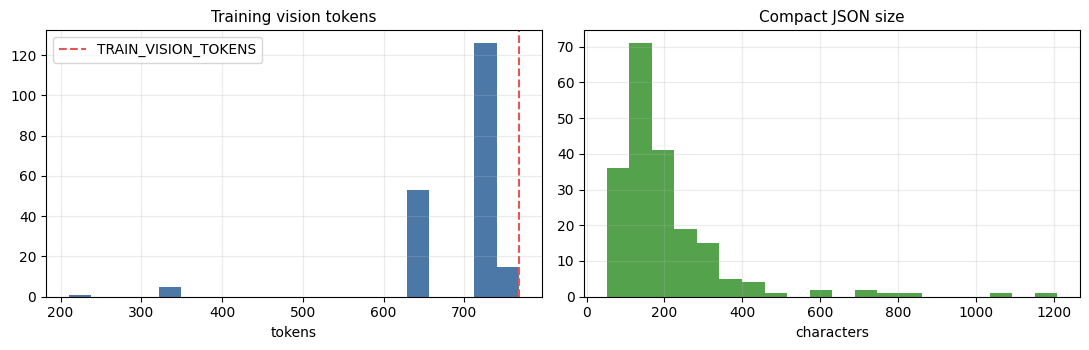

resized train images n=100


,count,mean,std,min,50%,95%,max
vision_tokens,100.0,697.8,78.5,345.0,726.0,768.0,768.0
json_chars,100.0,190.3,110.3,68.0,169.5,387.4,660.0


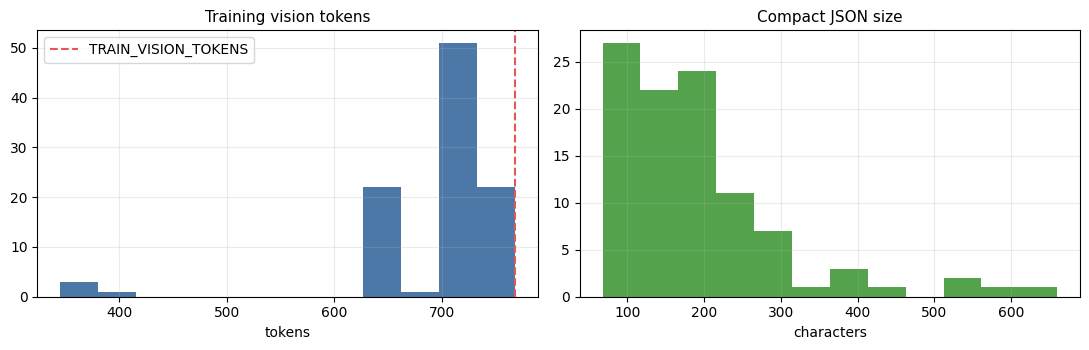

train rows 200 validation rows 100 test held out 100
budget: vision ≤ 768 max_seq 3072 ≈ room for JSON tokens 2256
==((====))==  Unsloth 2026.9.12: Fast Qwen2_5_Vl patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
total weights      : 2.238 GiB
no_split classes   : ['Qwen2_5_VLDecoderLayer', 'Qwen2_5_VLVisionBlock']
output head        : lm_head -> cuda:1
head headroom      : 0.359 GiB
activation reserve : 11.226 GiB requested
tied to head       : ['model.language_model.embed_tokens']
  cuda:0  budget  12.69 GiB  weights  1.443 GiB  free 11.247 GiB  reserve 11.226 GiB
  cuda:1  budget  12.36 GiB  weights  0.795 GiB  free 11.563 GiB  res

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

token budget


,max_seq,p50,p95,max,kept,dropped
0,3072,1036,1193,1527,200,0


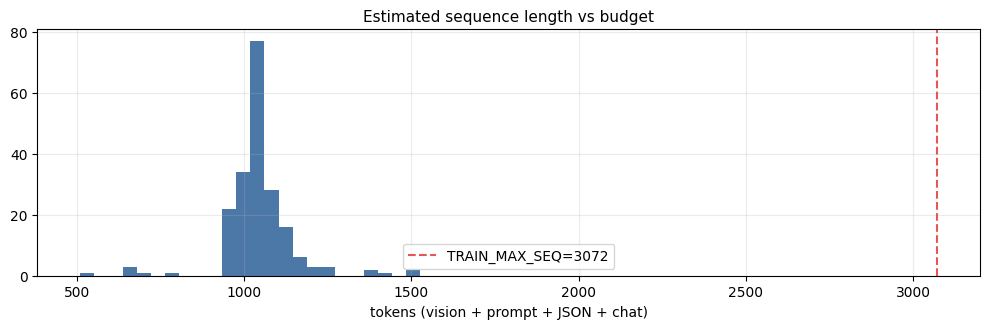

token budget


,max_seq,p50,p95,max,kept,dropped
0,3072,1048,1185,1236,100,0


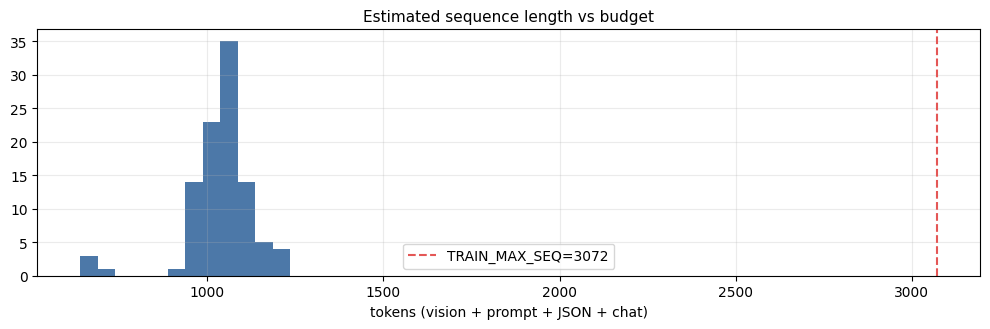

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 2
   \\   /|    Num examples = 200 | Num Epochs = 1 | Total steps = 25
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,784,556,544 (0.79% trained)


Step,Training Loss,Validation Loss
25,nan,nan


skip step 3: non-finite grad (#1)
skip step 8: non-finite grad (#2)
skip step 13: non-finite grad (#3)
skip step 14: non-finite grad (#4)
skip step 17: non-finite grad (#5)
skip step 18: non-finite grad (#6)
skip step 21: non-finite grad (#7)
skip step 22: non-finite grad (#8)
training log


,step,loss,learning_rate
0,1,7.1880,0.0
1,2,7.3362,0.0
2,3,7.5308,0.0
3,4,NaN,0.0
4,5,NaN,0.0
5,6,NaN,0.0
6,7,NaN,0.0
7,8,NaN,0.0
8,9,NaN,0.0
9,10,NaN,0.0


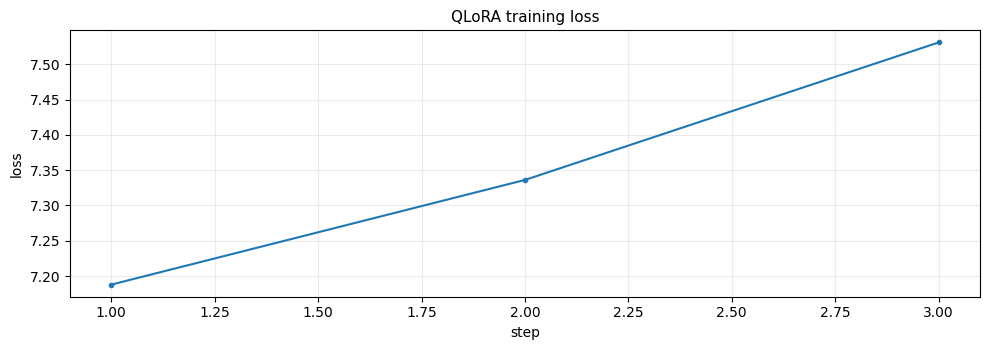

last loss nan last finite step 3
no finite checkpoint found; saved adapter may be NaN — re-run this cell
peak GPU GiB 5.9784464836120605


In [35]:
trained = False
if HAS_GPU and dataset is not None:
    if vlm.get("model") is not None:
        free_vlm()
    train_rows = convert_split(dataset["train"], MAX_TRAIN)
    validation_rows = convert_split(dataset["validation"], 0)
    print("train rows", len(train_rows), "validation rows", len(validation_rows), "test held out", len(splits["test"]))
    print(
        "budget: vision ≤", TRAIN_VISION_TOKENS,
        "max_seq", TRAIN_MAX_SEQ,
        "≈ room for JSON tokens", TRAIN_MAX_SEQ - TRAIN_VISION_TOKENS - CHAT_OVERHEAD,
    )
    try:
        train_unsloth(train_rows, validation_rows)
        trained = True
    except Exception as exc:
        print("Unsloth failed, falling back:", type(exc).__name__, exc)
        import gc
        gc.collect()
        if HAS_GPU:
            torch.cuda.empty_cache()
        try:
            train_hf(train_rows, validation_rows)
            trained = True
        except Exception as hf_exc:
            print("HuggingFace training also failed:", type(hf_exc).__name__, hf_exc)
    if HAS_GPU and trained:
        print("peak GPU GiB", torch.cuda.max_memory_allocated() / 1024**3)
else:
    print("skip training — need GPU + CORD")


## 9b. SROIE header-only fine-tune and held-out evaluation

This path trains a separate adapter using only SROIE company/date labels. A deterministic slice of the official SROIE train split is used for validation; the official test split is reserved for final evaluation and is never passed to the trainer.

In [43]:
HAS_GPU = bool(globals().get("HAS_GPU", False))


#### Helpers: `convert_sroie_header_rows`, `estimate_seq_len`, `infer_sroie_header_page`


In [ ]:
def convert_sroie_header_rows(rows):
    converted = []
    for row in rows:
        image = resize_image(row["image"], TRAIN_MIN_PIXELS, TRAIN_MAX_PIXELS)
        target = row["target"]
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text", "text": SROIE_HEADER_PROMPT},
                ],
            },
            {
                "role": "assistant",
                "content": [{"type": "text", "text": compact_target(target)}],
            },
        ]
        converted.append({"messages": messages})
    return converted


def estimate_seq_len(tokenizer, row):
    image = row["messages"][0]["content"][0]["image"]
    prompt = row["messages"][0]["content"][1]["text"]
    completion = row["messages"][1]["content"][0]["text"]
    text_ids = tokenizer(prompt + completion, add_special_tokens=False)["input_ids"]
    return vision_token_count(image) + len(text_ids) + CHAT_OVERHEAD


def infer_sroie_header_page(image, repair_hint=None):
    if vlm["model"] is None:
        raise RuntimeError("model not loaded")
    image = resize_image(image, EVAL_MIN_PIXELS, MAX_PIXELS)
    prompt = SROIE_HEADER_PROMPT
    if repair_hint:
        prompt = f"Previous output failed: {repair_hint}\n{SROIE_HEADER_PROMPT}"
    messages = [{"role": "user", "content": [{"type": "image", "image": image}, {"type": "text", "text": prompt}]}]
    rendered = vlm["processor"].apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = vlm["processor"](text=[rendered], images=[image], padding=True, return_tensors="pt")
    inputs = inputs.to(vlm["model"].device)
    output = vlm["model"].generate(**inputs, max_new_tokens=256, do_sample=False)
    trimmed = output[:, inputs["input_ids"].shape[1] :]
    return vlm["processor"].batch_decode(trimmed, skip_special_tokens=True)[0]


#### Helpers: `_sroie_header_scores`


In [ ]:
def _sroie_header_scores(golds, preds):
    fields = {}
    exact_receipts = []
    for field in ("store_name", "date"):
        tp = fp = fn = exact = labeled = 0
        for gold, pred in zip(golds, preds, strict=True):
            gold_value = gold.get(field)
            if gold_value is None:
                continue
            labeled += 1
            pred_value = pred.get(field)
            if pred_value is None:
                fn += 1
            elif normalize_text(str(gold_value)) == normalize_text(str(pred_value)):
                tp += 1
                exact += 1
            else:
                fp += 1
                fn += 1
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        fields[field] = {
            "labeled": labeled,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "exact_match": exact / labeled if labeled else 0.0,
        }
    for gold, pred in zip(golds, preds, strict=True):
        known_fields = [field for field in ("store_name", "date") if gold.get(field) is not None]
        if known_fields:
            exact_receipts.append(
                all(
                    pred.get(field) is not None
                    and normalize_text(str(gold[field])) == normalize_text(str(pred[field]))
                    for field in known_fields
                )
            )
    return {
        "fields": fields,
        "labeled_receipts": len(exact_receipts),
        "exact_match_header": sum(exact_receipts) / len(exact_receipts) if exact_receipts else 0.0,
    }


#### Helpers: `eval_sroie_headers`


In [ ]:
def eval_sroie_headers(rows, stage):
    golds, before_preds, after_preds, texts = [], [], [], []
    valid_json = 0
    for index, row in enumerate(rows):
        raw = None
        parsed = None
        error = "output was not a JSON object with store_name and date"
        for attempt in range(2):
            raw = infer_sroie_header_page(row["image"], error if attempt else None)
            try:
                blob = extract_json_object(raw or "")
                candidate = json.loads(blob) if blob else None
                if not isinstance(candidate, dict) or not {"store_name", "date"}.issubset(candidate):
                    raise ValueError(error)
                parsed = {
                    "store_name": _null_placeholder(candidate.get("store_name")),
                    "date": normalize_sroie_date(candidate.get("date")),
                }
                valid_json += 1
                break
            except (ValueError, json.JSONDecodeError) as exc:
                error = str(exc)
        if parsed is None:
            parsed = {"store_name": None, "date": None}
        before_preds.append(parsed)
        after_preds.append(
            ground_receipt(
                {
                    **parsed,
                    "line_items": [],
                    "subtotal": None,
                    "tax": None,
                    "total": None,
                },
                row.get("text") or "",
            )
        )
        golds.append(row["target"])
        texts.append(row.get("text") or "")
        print(f"{stage} {index + 1}/{len(rows)} receipt={row['id']}")
    before_metrics = _sroie_header_scores(golds, before_preds)
    after_metrics = _sroie_header_scores(golds, after_preds)
    result = {
        "stage": stage,
        "n": len(rows),
        "json_validity": valid_json / len(rows) if rows else 0.0,
        "pre_grounding": {
            **before_metrics,
            "hallucination_rate": hallucination_rate(before_preds, texts, after_grounding=False),
        },
        "post_grounding": {
            **after_metrics,
            "hallucination_rate": hallucination_rate(after_preds, texts, after_grounding=True),
        },
    }
    print(json.dumps(result, indent=2))
    return result


sroie_header_trained = False
sroie_header_results = {}


#### Configuration and Execution


SROIE header messages 563 validation 63 held-out test 361
==((====))==  Unsloth 2026.9.12: Fast Qwen2_5_Vl patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
total weights      : 2.238 GiB
no_split classes   : ['Qwen2_5_VLDecoderLayer', 'Qwen2_5_VLVisionBlock']
output head        : lm_head -> cuda:1
head headroom      : 0.359 GiB
activation reserve : 11.578 GiB requested
tied to head       : ['model.language_model.embed_tokens']
  cuda:0  budget  12.87 GiB  weights  1.264 GiB  free 11.604 GiB  reserve 11.578 GiB
  cuda:1  budget  12.89 GiB  weights  0.975 GiB  free 11.911 GiB  reserve 11.408 GiB   <- output head
note: Bnb4BitHfQuantizer

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

token budget


,max_seq,p50,p95,max,kept,dropped
0,3072,855,880,888,563,0


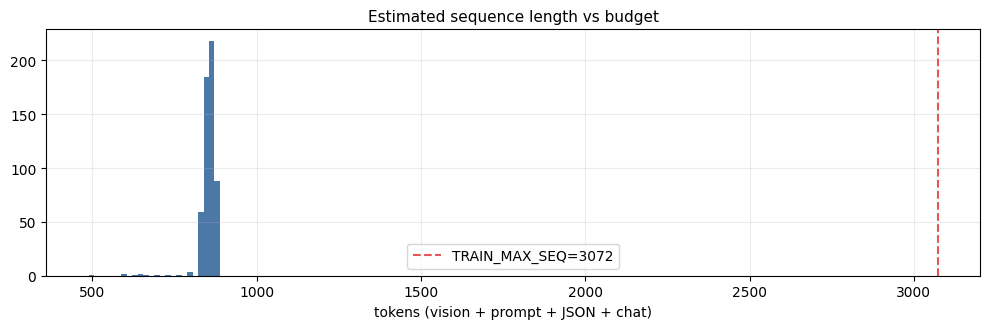

token budget


,max_seq,p50,p95,max,kept,dropped
0,3072,854,883,887,63,0


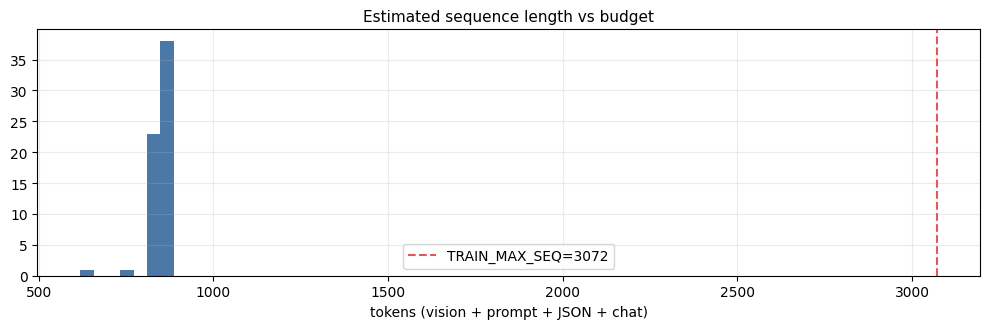

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 2
   \\   /|    Num examples = 563 | Num Epochs = 1 | Total steps = 71
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,784,556,544 (0.79% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
25,7.103761,7.134055
50,7.497725,7.106963
71,7.597391,7.102973


Unsloth: Restored added_tokens_decoder metadata in outputs/lora-sroie-header/checkpoint-25/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/lora-sroie-header/checkpoint-71/tokenizer_config.json.


training log


,step,loss,learning_rate
0,1,6.9775,0.0
1,2,7.3742,0.0
2,3,7.0663,0.0
3,4,7.3626,0.0
4,5,7.1812,0.0
...,...,...,...
66,67,7.0565,0.0
67,68,7.4427,0.0
68,69,7.1259,0.0
69,70,7.1050,0.0


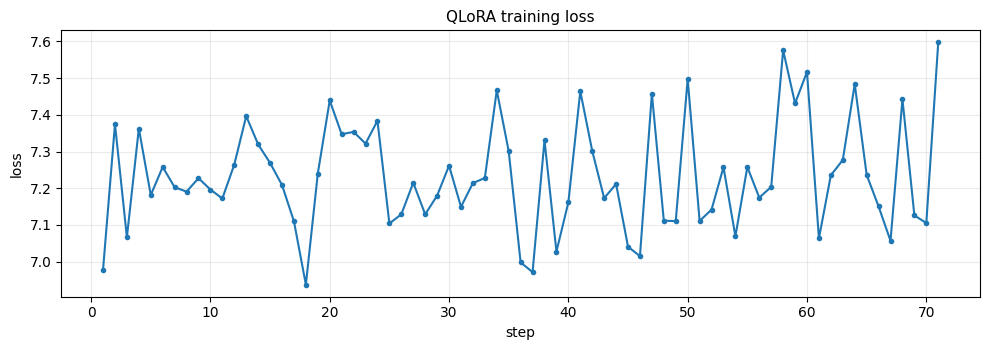

last loss 7.597390651702881 last finite step 71


Unsloth: Restored added_tokens_decoder metadata in outputs/lora-sroie-header/tokenizer_config.json.


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

loaded Qwen/Qwen2.5-VL-3B-Instruct adapter base
SROIE zero-shot 1/361 receipt=test-0
SROIE zero-shot 2/361 receipt=test-1
SROIE zero-shot 3/361 receipt=test-2
SROIE zero-shot 4/361 receipt=test-3
SROIE zero-shot 5/361 receipt=test-4
SROIE zero-shot 6/361 receipt=test-5
SROIE zero-shot 7/361 receipt=test-6
SROIE zero-shot 8/361 receipt=test-7
SROIE zero-shot 9/361 receipt=test-8
SROIE zero-shot 10/361 receipt=test-9
SROIE zero-shot 11/361 receipt=test-10
SROIE zero-shot 12/361 receipt=test-11
SROIE zero-shot 13/361 receipt=test-12
SROIE zero-shot 14/361 receipt=test-13
SROIE zero-shot 15/361 receipt=test-14
SROIE zero-shot 16/361 receipt=test-15
SROIE zero-shot 17/361 receipt=test-16
SROIE zero-shot 18/361 receipt=test-17
SROIE zero-shot 19/361 receipt=test-18
SROIE zero-shot 20/361 receipt=test-19
SROIE zero-shot 21/361 receipt=test-20
SROIE zero-shot 22/361 receipt=test-21
SROIE zero-shot 23/361 receipt=test-22
SROIE zero-shot 24/361 receipt=test-23
SROIE zero-shot 25/361 receipt=test

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

loaded Qwen/Qwen2.5-VL-3B-Instruct adapter outputs/lora-sroie-header
SROIE header-fine-tuned 1/361 receipt=test-0
SROIE header-fine-tuned 2/361 receipt=test-1
SROIE header-fine-tuned 3/361 receipt=test-2
SROIE header-fine-tuned 4/361 receipt=test-3
SROIE header-fine-tuned 5/361 receipt=test-4
SROIE header-fine-tuned 6/361 receipt=test-5
SROIE header-fine-tuned 7/361 receipt=test-6
SROIE header-fine-tuned 8/361 receipt=test-7
SROIE header-fine-tuned 9/361 receipt=test-8
SROIE header-fine-tuned 10/361 receipt=test-9
SROIE header-fine-tuned 11/361 receipt=test-10
SROIE header-fine-tuned 12/361 receipt=test-11
SROIE header-fine-tuned 13/361 receipt=test-12
SROIE header-fine-tuned 14/361 receipt=test-13
SROIE header-fine-tuned 15/361 receipt=test-14
SROIE header-fine-tuned 16/361 receipt=test-15
SROIE header-fine-tuned 17/361 receipt=test-16
SROIE header-fine-tuned 18/361 receipt=test-17
SROIE header-fine-tuned 19/361 receipt=test-18
SROIE header-fine-tuned 20/361 receipt=test-19
SROIE head

In [37]:
if not HAS_GPU:
    print("skip SROIE header training/evaluation — GPU required")
elif not sroie_train_rows:
    print("skip SROIE header training/evaluation — SROIE train split unavailable")
else:
    sroie_train_messages = convert_sroie_header_rows(sroie_train_rows)
    sroie_validation_messages = convert_sroie_header_rows(sroie_validation_rows)
    print(
        "SROIE header messages", len(sroie_train_messages),
        "validation", len(sroie_validation_messages),
        "held-out test", len(sroie_eval_rows),
    )
    original_adapter_dir = ADAPTER_DIR
    original_train_epochs = TRAIN_EPOCHS
    ADAPTER_DIR = SROIE_ADAPTER_DIR
    TRAIN_EPOCHS = int(os.environ.get("SROIE_TRAIN_EPOCHS", str(original_train_epochs)))
    try:
        if vlm.get("model") is not None:
            free_vlm()
        try:
            train_unsloth(sroie_train_messages, sroie_validation_messages or None)
            sroie_header_trained = True
        except Exception as exc:
            print("SROIE Unsloth training failed, falling back:", type(exc).__name__, exc)
            import gc

            gc.collect()
            torch.cuda.empty_cache()
            try:
                train_hf(sroie_train_messages, sroie_validation_messages or None)
                sroie_header_trained = True
            except Exception as hf_exc:
                print("SROIE HuggingFace training failed:", type(hf_exc).__name__, hf_exc)
    finally:
        ADAPTER_DIR = original_adapter_dir
        TRAIN_EPOCHS = original_train_epochs

    if sroie_header_trained and sroie_eval_rows:
        eval_limit = int(os.environ.get("MAX_SROIE_EVAL", "0"))
        sroie_test_rows = sroie_eval_rows[:eval_limit] if eval_limit else sroie_eval_rows
        try:
            if vlm.get("model") is not None:
                free_vlm()
            load_vlm()
            sroie_header_results["zero-shot"] = eval_sroie_headers(sroie_test_rows, "SROIE zero-shot")
            free_vlm()
            load_vlm(SROIE_ADAPTER_DIR)
            sroie_header_results["header-fine-tuned"] = eval_sroie_headers(
                sroie_test_rows, "SROIE header-fine-tuned"
            )
        finally:
            if vlm.get("model") is not None:
                free_vlm()
        payload = json.dumps(sroie_header_results, indent=2)
        (WORK / "sroie_header_metrics.json").write_text(payload, encoding="utf-8")
        print("wrote", WORK / "sroie_header_metrics.json")
    elif sroie_header_trained:
        print("SROIE header adapter trained; no official test split to evaluate")


## 10. Fine-tuned eval, comparison, optional Hub push

Reload the adapter and score the **same** `eval_rows` as zero-shot. The comparison table is the assignment result: compare quality and latency against the zero-shot baseline on the same frozen ids.


In [45]:
if "_eval_vlm_full" not in globals():
    _eval_vlm_full = eval_vlm


def eval_vlm(rows, stage):
    if stage != "fine-tuned":
        return _eval_vlm_full(rows, stage)

    base_outputs = raw_eval_outputs.get("zero-shot") or []
    base_ids = raw_eval_ids.get("zero-shot") or []
    row_ids = [str(row.get("id", index)) for index, row in enumerate(rows)]
    if not base_outputs or base_ids != row_ids:
        print("skip fine-tuned run: no zero-shot baseline for the same receipt ids")
        return None

    sample_count = min(8, len(rows))
    smoke_outputs = [infer_page(rows[index]["image"]) for index in range(sample_count)]
    changed = sum(
        smoke != base_outputs[index]
        for index, smoke in enumerate(smoke_outputs)
    )
    print(f"adapter smoke check: outputs changed for {changed}/{sample_count} matched receipts")
    if changed == 0:
        print("skip full fine-tuned evaluation; verify adapter loading and training before more tuning")
        return None
    return _eval_vlm_full(rows, stage)


#### Helpers: `_field_score`, `compare_stages`


In [ ]:
def _field_score(stage, name, leaf=None):
    block = stage["fields"][name]
    return (block[leaf] if leaf else block)["f1"], (block[leaf] if leaf else block)["exact_match"]


def compare_stages(zero_shot, fine_tuned):
    if not zero_shot or not fine_tuned:
        print("need both stages to compare")
        return
    pairs = [
        ("store_name", None),
        ("date", None),
        ("subtotal", None),
        ("tax", None),
        ("total", None),
        ("line_items", "name"),
        ("line_items", "qty"),
        ("line_items", "unit_price"),
        ("line_items", "amount"),
    ]
    print("zero-shot vs fine-tuned (same test ids)")
    print("CORD gold store_name/date are always null — F1 stays 0; Exact rising means fewer invented headers.")
    print("Want line_items.name/qty up without dropping tax/total.")
    rows = []
    for name, leaf in pairs:
        zf, ze = _field_score(zero_shot, name, leaf)
        ff, fe = _field_score(fine_tuned, name, leaf)
        rows.append({
            "field": f"{name}.{leaf}" if leaf else name,
            "zs_f1": zf,
            "ft_f1": ff,
            "delta_f1": ff - zf,
            "zs_exact": ze,
            "ft_exact": fe,
            "delta_exact": fe - ze,
        })
    if pd is None:
        print(rows)
        return
    df = pd.DataFrame(rows)
    _show_df(df.round(3))
    if plt is None:
        return
    _style_plot()
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
    x = range(len(df))
    axes[0].bar([i - 0.2 for i in x], df["zs_f1"], width=0.4, label="zero-shot")
    axes[0].bar([i + 0.2 for i in x], df["ft_f1"], width=0.4, label="fine-tuned")
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(df["field"], rotation=35, ha="right")
    axes[0].set_ylim(0, 1.05)
    axes[0].set_ylabel("F1")
    axes[0].set_title("Field F1: zero-shot vs fine-tuned")
    axes[0].legend()
    colors = ["#54A24B" if v >= 0 else "#E45756" for v in df["delta_f1"]]
    axes[1].barh(df["field"][::-1], df["delta_f1"][::-1], color=colors[::-1])
    axes[1].axvline(0, color="#333", linewidth=0.8)
    axes[1].set_xlabel("Δ F1 (fine-tuned − zero-shot)")
    axes[1].set_title("F1 change after QLoRA")
    fig.tight_layout()
    plt.show()


fine_tuned = None


#### Configuration and Execution


freed eval VLM (required before QLoRA — T4 cannot hold two 3B copies)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

loaded Qwen/Qwen2.5-VL-3B-Instruct adapter outputs/lora
adapter smoke check: outputs changed for 0/8 matched receipts
skip full fine-tuned evaluation; verify adapter loading and training before more tuning
raw comparison unavailable: run both evaluation stages
zero-shot  n=32  receipt_exact=0.188  hallu=0.000  latency_ms p50/p95=23670.27419499982/47361.569829000015  gpu=3.01 GiB


,field,precision,recall,f1,exact_match,labeled,ignored_unlabeled
0,store_name,0.000,0.000,0.000,0.000,0,32
1,date,0.000,0.000,0.000,0.000,0,32
2,subtotal,0.778,0.667,0.718,0.667,21,11
3,tax,0.636,0.500,0.560,0.500,14,18
4,total,0.667,0.581,0.621,0.581,31,1
5,line_items.name,0.843,0.702,0.766,0.663,89,0
6,line_items.qty,0.935,0.795,0.859,0.753,77,12
7,line_items.unit_price,0.429,0.375,0.400,0.300,20,69
8,line_items.amount,0.714,0.556,0.625,0.523,86,3


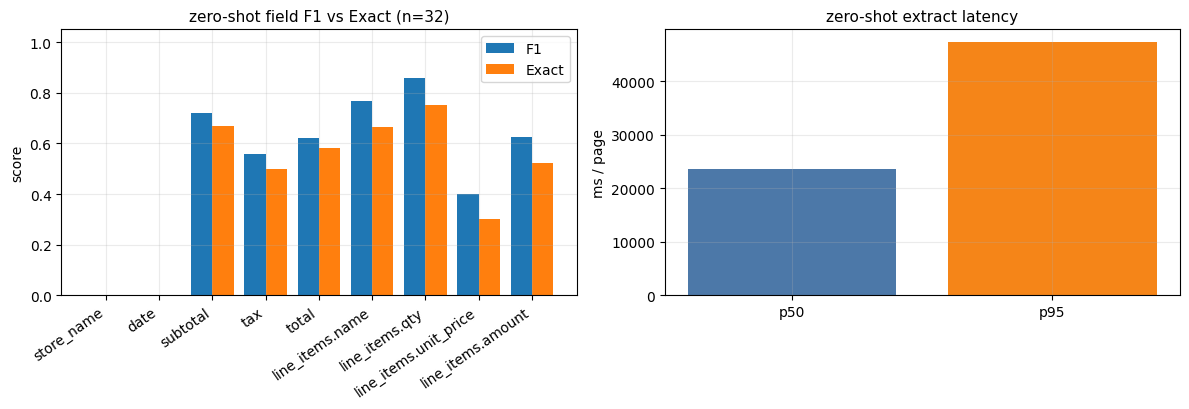

need both stages to compare
wrote pipeline_out/metrics.json


eval/loss,█▂▁
eval/runtime,█▆▁▁▁
eval/samples_per_second,▁▅███
eval/steps_per_second,▁▄███
train/epoch,▁▁▂▃▄▅▆▇▇▂▄▄▂▃▄▇▇█▁▁▃▃▃▄▄▄▅▅▆▆▆▇▇▇▇█████
train/global_step,▁▁▂▂▃▃▁▂▁▁▁▁▂▂▂▃▃▃▃▁▂▂▃▃▃▃▃▄▄▅▅▅▅▆▆▇▇▇▇█
train/grad_norm,▇██▅▅▅ █ ████▅█▄▅▆ ▅ ▁▁▁▁▂▁▂▁▁▁▁▁▁▁▂▁▁▂
train/learning_rate,▇██▇▇▅▅▅▄▅█▂▇██▇▇▆▁▂▃▄▅▇▇█████▇▆▆▅▅▃▂▂▂▁
train/loss,▄▅ ▅▇ ▅ ▁▂▄▄▆▁▄▄▇▅▂▁▃▂▇▄▄▆▄▇▆█
eval/loss,7.10297
eval/runtime,68.0686


HfHubHTTPError: Client error '401 Unauthorized' for url 'https://huggingface.co/api/repos/create' (Request ID: Root=1-6abd359f-4699f11776af18bd545a0e6d;623fdf32-64ec-437c-9322-93d51f5f2ca1)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/401

Invalid username or password.

In [46]:
if trained and HAS_GPU:
    free_vlm()
    import gc
    gc.collect()
    if HAS_GPU:
        torch.cuda.empty_cache()
    load_vlm(ADAPTER_DIR)
    fine_tuned = eval_vlm(eval_rows, "fine-tuned")

compare_raw_outputs()

stages = [s for s in (zero_shot, fine_tuned) if s]
report = {
    "note": "Standalone notebook. Test ids never used in training.",
    "stages": stages,
    "hardware": "T4" if HAS_GPU else "CPU (VLM stages skipped)",
}
payload = json.dumps(report, indent=2)
(WORK / "metrics.json").write_text(payload, encoding="utf-8")
try:
    Path("notebooks").mkdir(exist_ok=True)
    Path("notebooks/metrics.json").write_text(payload, encoding="utf-8")
except Exception:
    pass

for stage in stages:
    show_table(stage)
compare_stages(zero_shot, fine_tuned)
if not stages:
    print("No VLM stages. CPU demo above still ran the full post-process pipeline.")
print("wrote", WORK / "metrics.json")

if os.environ.get("WANDB_API_KEY") and stages:
    try:
        import wandb

        run = wandb.run or wandb.init(project=os.environ.get("WANDB_PROJECT", "vlm-receipt-extraction"))
        table = wandb.Table(columns=["stage", "field", "f1", "exact"])
        for stage in stages:
            for name, scores in stage["fields"].items():
                if name == "line_items":
                    for leaf, leaf_scores in scores.items():
                        table.add_data(stage["stage"], f"line_items.{leaf}", leaf_scores["f1"], leaf_scores["exact_match"])
                else:
                    table.add_data(stage["stage"], name, scores["f1"], scores["exact_match"])
        run.log({"comparison": table})
        wandb.finish()
    except Exception as exc:
        print("wandb log skipped", exc)


In [ ]:
os.environ["HF_PUSH"] = "1"
if os.environ.get("HF_PUSH") == "1" and ADAPTER_DIR.exists():
    from huggingface_hub import HfApi

    api = HfApi()
    api.create_repo(HF_ADAPTER_REPO, exist_ok=True, private=True)
    api.upload_folder(folder_path=str(ADAPTER_DIR), repo_id=HF_ADAPTER_REPO)
    print("pushed", HF_ADAPTER_REPO)
else:
    print("adapter local at", ADAPTER_DIR, "— set HF_PUSH=1 to upload to", HF_ADAPTER_REPO)


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

pushed mahesh-nallada/vlm-receipt-extraction-lora


freed eval VLM (required before QLoRA — T4 cannot hold two 3B copies)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

loaded Qwen/Qwen2.5-VL-3B-Instruct adapter base
comparison-zero-shot 1/32 receipt=0
comparison-zero-shot 2/32 receipt=1
comparison-zero-shot 3/32 receipt=2
comparison-zero-shot 4/32 receipt=3
comparison-zero-shot 5/32 receipt=4
comparison-zero-shot 6/32 receipt=5
comparison-zero-shot 7/32 receipt=6
comparison-zero-shot 8/32 receipt=7
comparison-zero-shot 9/32 receipt=8
comparison-zero-shot 10/32 receipt=9
comparison-zero-shot 11/32 receipt=10
comparison-zero-shot 12/32 receipt=11
comparison-zero-shot 13/32 receipt=12
comparison-zero-shot 14/32 receipt=13
comparison-zero-shot 15/32 receipt=14
comparison-zero-shot 16/32 receipt=15
comparison-zero-shot 17/32 receipt=16
comparison-zero-shot 18/32 receipt=17
comparison-zero-shot 19/32 receipt=18
comparison-zero-shot 20/32 receipt=19
comparison-zero-shot 21/32 receipt=20
comparison-zero-shot 22/32 receipt=21
comparison-zero-shot 23/32 receipt=22
comparison-zero-shot 24/32 receipt=23
comparison-zero-shot 25/32 receipt=24
comparison-zero-shot 

,receipt_id,gold_items,before_items,after_items,missing_names_before,missing_names_after,extra_names_before,extra_names_after,fields_removed_by_grounding,exact_before,exact_after
0,0,1,1,1,[],[],[],[],3,False,False
1,1,3,2,2,[J.STB PROMO],[J.STB PROMO],[],[],3,False,False
2,2,2,2,2,[],[],[],[],2,False,False
3,3,1,1,1,[],[],[],[],2,True,True
4,4,3,0,0,"[ICE BLACKCOFFE, AVOCADO COFFEE, CHIKEN KATSU FF]","[ICE BLACKCOFFE, AVOCADO COFFEE, CHIKEN KATSU FF]",[],[],0,False,False
5,5,1,1,1,[TRAD KY TOAST CARTE],[TRAD KY TOAST CARTE],[ITEMS 1.00],[ITEMS 1.00],0,False,False
6,6,3,3,2,[],[CHOCO CUS ARD PASTRY],[],[],4,False,False
7,7,2,1,1,[Kupon 15],[Kupon 15],[],[],0,False,False
8,8,3,3,2,[],[[REG] BLACK SAKURA],[],[],4,False,False
9,9,1,1,0,[],[Bumbu Kaldu Ayam 1],[],[],4,False,False


comparison-zero-shot  n=32  receipt_exact=0.188  hallu=0.000  latency_ms p50/p95=23264.381254997716/47048.28951300078  gpu=1.24 GiB


,field,precision,recall,f1,exact_match,labeled,ignored_unlabeled
0,store_name,0.000,0.000,0.000,0.000,0,32
1,date,0.000,0.000,0.000,0.000,0,32
2,subtotal,0.778,0.667,0.718,0.667,21,11
3,tax,0.636,0.500,0.560,0.500,14,18
4,total,0.667,0.581,0.621,0.581,31,1
5,line_items.name,0.843,0.702,0.766,0.663,89,0
6,line_items.qty,0.935,0.795,0.859,0.753,77,12
7,line_items.unit_price,0.429,0.375,0.400,0.300,20,69
8,line_items.amount,0.714,0.556,0.625,0.523,86,3


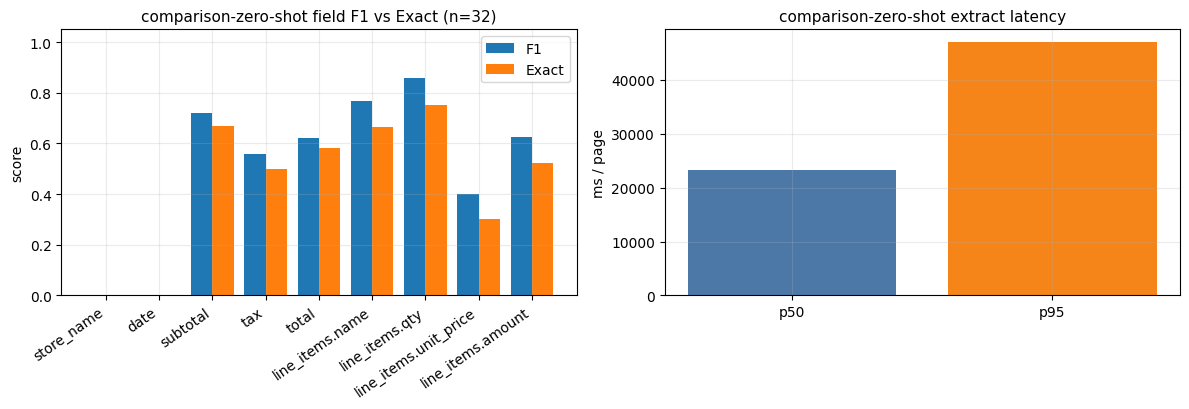

comparison-zero-shot results: actual, ground truth, raw prediction, final prediction


,stage,receipt_id,actual,ground_truth,raw_predicted,pred
0,comparison-zero-shot,0,901016\n-TICKET CP\n2\n60.000\n60.000\nTOTAL D...,"{'line_items': [{'name': '-TICKET CP', 'qty': ...","```json\n{\n ""store_name"": ""B. B"",\n ""date"":...","{'store_name': None, 'date': None, 'line_items..."
1,comparison-zero-shot,1,J.STB PROMO\n17500\nY.B.BAT\n46000\nY.BASO PRO...,"{'line_items': [{'name': 'J.STB PROMO', 'amoun...","```json\n{\n ""store_name"": ""J.STB PROMO"",\n...","{'store_name': 'J.STB PROMO', 'date': None, 'l..."
2,comparison-zero-shot,2,"1\nJASMINE MT ( L )\n24,000\nCOCONUT JELLY ( L...","{'line_items': [{'name': 'JASMINE MT ( L )', '...","```json\n{\n ""store_name"": ""BINTANG"",\n ...","{'store_name': None, 'date': None, 'line_items..."
3,comparison-zero-shot,3,"1X\n@11000\nDONAT GULA\n11,000\n1.00xITEMs\nSU...","{'line_items': [{'name': 'DONAT GULA', 'qty': ...","```json\n{\n ""store_name"": ""Dynamic Natural...","{'store_name': None, 'date': None, 'line_items..."
4,comparison-zero-shot,4,"ICE BLACKCOFFE\n2\n82,000\nAVOCADO COFFEE\n1\n...","{'line_items': [{'name': 'ICE BLACKCOFFE', 'qt...",!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!...,"{'store_name': None, 'date': None, 'line_items..."
5,comparison-zero-shot,5,TRAD KY TOAST CARTE\n28.182\nITEMS 1.00\nSUBTT...,{'line_items': [{'name': 'TRAD KY TOAST CARTE'...,"```json\n{\n ""store_name"": ""TRAD KY TOAST CAR...","{'store_name': 'TRAD KY TOAST CARTE', 'date': ..."
6,comparison-zero-shot,6,"1\nEGG TART\n13,000\n2\nCHOCO CUS ARD PASTRY\n...","{'line_items': [{'name': 'EGG TART', 'qty': 1....","```json\n{\n ""store_name"": null,\n ""date"": n...","{'store_name': None, 'date': None, 'line_items..."
7,comparison-zero-shot,7,"Kupon 15\n100,000\nADD CHICKEN BOX\n909\nSubto...","{'line_items': [{'name': 'Kupon 15', 'amount':...","```json\n{\n ""store_name"": ""Kupon 15"",\n ""da...","{'store_name': 'Kupon 15', 'date': None, 'line..."
8,comparison-zero-shot,8,"1\n[REG] BLACK SAKURA\n45,455\n1\nCOOKIE DOH S...","{'line_items': [{'name': '[REG] BLACK SAKURA',...","```json\n{\n ""store_name"": null,\n ""date"": n...","{'store_name': None, 'date': None, 'line_items..."
9,comparison-zero-shot,9,Bumbu Kaldu Ayam 1\n36000\n36000\nSub Total 36...,"{'line_items': [{'name': 'Bumbu Kaldu Ayam 1',...","```json\n{\n ""store_name"": null,\n ""date"": n...","{'store_name': None, 'date': None, 'line_items..."


freed eval VLM (required before QLoRA — T4 cannot hold two 3B copies)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

loaded Qwen/Qwen2.5-VL-3B-Instruct adapter outputs/lora
comparison-fine-tuned 1/32 receipt=0
comparison-fine-tuned 2/32 receipt=1
comparison-fine-tuned 3/32 receipt=2
comparison-fine-tuned 4/32 receipt=3
comparison-fine-tuned 5/32 receipt=4
comparison-fine-tuned 6/32 receipt=5
comparison-fine-tuned 7/32 receipt=6
comparison-fine-tuned 8/32 receipt=7
comparison-fine-tuned 9/32 receipt=8
comparison-fine-tuned 10/32 receipt=9
comparison-fine-tuned 11/32 receipt=10
comparison-fine-tuned 12/32 receipt=11
comparison-fine-tuned 13/32 receipt=12
comparison-fine-tuned 14/32 receipt=13
comparison-fine-tuned 15/32 receipt=14
comparison-fine-tuned 16/32 receipt=15
comparison-fine-tuned 17/32 receipt=16
comparison-fine-tuned 18/32 receipt=17
comparison-fine-tuned 19/32 receipt=18
comparison-fine-tuned 20/32 receipt=19
comparison-fine-tuned 21/32 receipt=20
comparison-fine-tuned 22/32 receipt=21
comparison-fine-tuned 23/32 receipt=22
comparison-fine-tuned 24/32 receipt=23
comparison-fine-tuned 25/32

,receipt_id,gold_items,before_items,after_items,missing_names_before,missing_names_after,extra_names_before,extra_names_after,fields_removed_by_grounding,exact_before,exact_after
0,0,1,1,1,[],[],[],[],3,False,False
1,1,3,2,2,[J.STB PROMO],[J.STB PROMO],[],[],3,False,False
2,2,2,2,2,[],[],[],[],2,False,False
3,3,1,1,1,[],[],[],[],2,True,True
4,4,3,0,0,"[ICE BLACKCOFFE, AVOCADO COFFEE, CHIKEN KATSU FF]","[ICE BLACKCOFFE, AVOCADO COFFEE, CHIKEN KATSU FF]",[],[],0,False,False
5,5,1,1,1,[TRAD KY TOAST CARTE],[TRAD KY TOAST CARTE],[ITEMS 1.00],[ITEMS 1.00],0,False,False
6,6,3,3,2,[],[CHOCO CUS ARD PASTRY],[],[],4,False,False
7,7,2,1,1,[Kupon 15],[Kupon 15],[],[],0,False,False
8,8,3,3,2,[],[[REG] BLACK SAKURA],[],[],4,False,False
9,9,1,1,0,[],[Bumbu Kaldu Ayam 1],[],[],4,False,False


comparison-fine-tuned  n=32  receipt_exact=0.219  hallu=0.000  latency_ms p50/p95=39746.39008899976/81181.5492220012  gpu=1.24 GiB


,field,precision,recall,f1,exact_match,labeled,ignored_unlabeled
0,store_name,0.000,0.000,0.000,0.000,0,32
1,date,0.000,0.000,0.000,0.000,0,32
2,subtotal,0.778,0.667,0.718,0.667,21,11
3,tax,0.636,0.500,0.560,0.500,14,18
4,total,0.704,0.613,0.655,0.613,31,1
5,line_items.name,0.843,0.702,0.766,0.663,89,0
6,line_items.qty,0.935,0.795,0.859,0.753,77,12
7,line_items.unit_price,0.429,0.375,0.400,0.300,20,69
8,line_items.amount,0.714,0.556,0.625,0.523,86,3


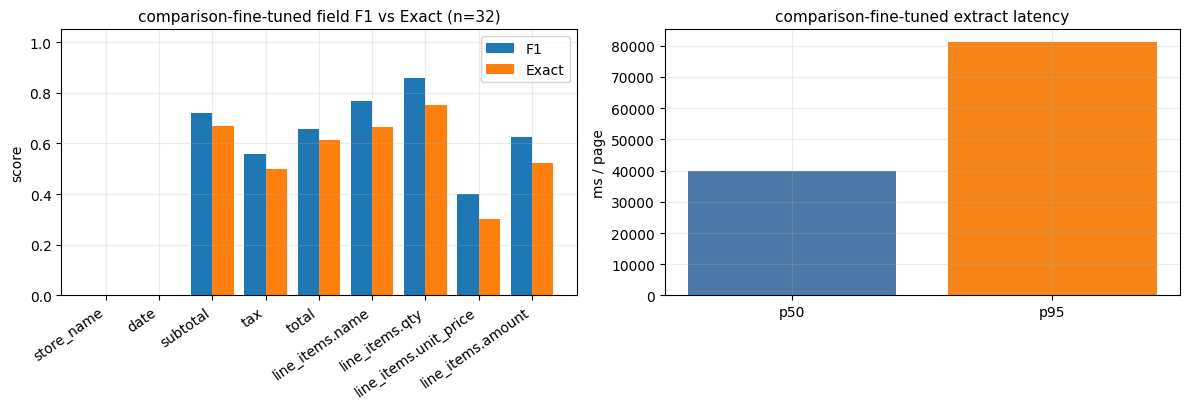

comparison-fine-tuned results: actual, ground truth, raw prediction, final prediction


,stage,receipt_id,actual,ground_truth,raw_predicted,pred
0,comparison-fine-tuned,0,901016\n-TICKET CP\n2\n60.000\n60.000\nTOTAL D...,"{'line_items': [{'name': '-TICKET CP', 'qty': ...","```json\n{\n ""store_name"": ""B. B"",\n ""date"":...","{'store_name': None, 'date': None, 'line_items..."
1,comparison-fine-tuned,1,J.STB PROMO\n17500\nY.B.BAT\n46000\nY.BASO PRO...,"{'line_items': [{'name': 'J.STB PROMO', 'amoun...","```json\n{\n ""store_name"": ""J.STB PROMO"",\n...","{'store_name': 'J.STB PROMO', 'date': None, 'l..."
2,comparison-fine-tuned,2,"1\nJASMINE MT ( L )\n24,000\nCOCONUT JELLY ( L...","{'line_items': [{'name': 'JASMINE MT ( L )', '...","```json\n{\n ""store_name"": ""BINTANG"",\n ...","{'store_name': None, 'date': None, 'line_items..."
3,comparison-fine-tuned,3,"1X\n@11000\nDONAT GULA\n11,000\n1.00xITEMs\nSU...","{'line_items': [{'name': 'DONAT GULA', 'qty': ...","```json\n{\n ""store_name"": ""Dynamic Natural...","{'store_name': None, 'date': None, 'line_items..."
4,comparison-fine-tuned,4,"ICE BLACKCOFFE\n2\n82,000\nAVOCADO COFFEE\n1\n...","{'line_items': [{'name': 'ICE BLACKCOFFE', 'qt...",!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!...,"{'store_name': None, 'date': None, 'line_items..."
5,comparison-fine-tuned,5,TRAD KY TOAST CARTE\n28.182\nITEMS 1.00\nSUBTT...,{'line_items': [{'name': 'TRAD KY TOAST CARTE'...,"```json\n{\n ""store_name"": ""TRAD KY TOAST CAR...","{'store_name': 'TRAD KY TOAST CARTE', 'date': ..."
6,comparison-fine-tuned,6,"1\nEGG TART\n13,000\n2\nCHOCO CUS ARD PASTRY\n...","{'line_items': [{'name': 'EGG TART', 'qty': 1....","```json\n{\n ""store_name"": null,\n ""date"": n...","{'store_name': None, 'date': None, 'line_items..."
7,comparison-fine-tuned,7,"Kupon 15\n100,000\nADD CHICKEN BOX\n909\nSubto...","{'line_items': [{'name': 'Kupon 15', 'amount':...","```json\n{\n ""store_name"": ""Kupon 15"",\n ""da...","{'store_name': 'Kupon 15', 'date': None, 'line..."
8,comparison-fine-tuned,8,"1\n[REG] BLACK SAKURA\n45,455\n1\nCOOKIE DOH S...","{'line_items': [{'name': '[REG] BLACK SAKURA',...","```json\n{\n ""store_name"": null,\n ""date"": n...","{'store_name': None, 'date': None, 'line_items..."
9,comparison-fine-tuned,9,Bumbu Kaldu Ayam 1\n36000\n36000\nSub Total 36...,"{'line_items': [{'name': 'Bumbu Kaldu Ayam 1',...","```json\n{\n ""store_name"": null,\n ""date"": n...","{'store_name': None, 'date': None, 'line_items..."


freed eval VLM (required before QLoRA — T4 cannot hold two 3B copies)
Comparison complete
same receipt ids: 32
zero-shot vs fine-tuned (same test ids)
CORD gold store_name/date are always null — F1 stays 0; Exact rising means fewer invented headers.
Want line_items.name/qty up without dropping tax/total.


,field,zs_f1,ft_f1,delta_f1,zs_exact,ft_exact,delta_exact
0,store_name,0.000,0.000,0.000,0.000,0.000,0.000
1,date,0.000,0.000,0.000,0.000,0.000,0.000
2,subtotal,0.718,0.718,0.000,0.667,0.667,0.000
3,tax,0.560,0.560,0.000,0.500,0.500,0.000
4,total,0.621,0.655,0.034,0.581,0.613,0.032
5,line_items.name,0.766,0.766,0.000,0.663,0.663,0.000
6,line_items.qty,0.859,0.859,0.000,0.753,0.753,0.000
7,line_items.unit_price,0.400,0.400,0.000,0.300,0.300,0.000
8,line_items.amount,0.625,0.625,0.000,0.523,0.523,0.000


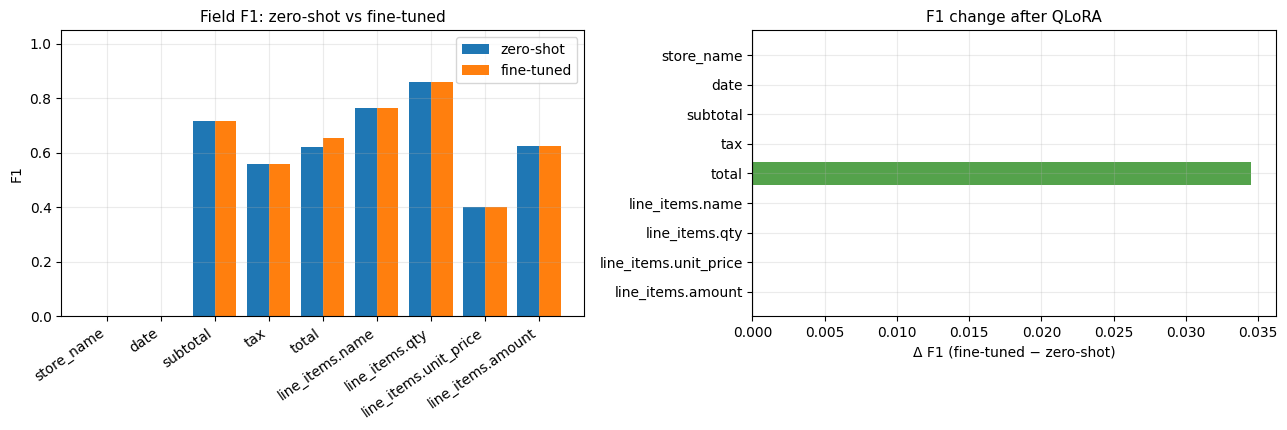

wrote pipeline_out/full_comparison.json
wrote notebooks/full_comparison.json


In [49]:
# Full same-test-set comparison: base model vs. the trained LoRA adapter.
# Run this cell after the setup, CORD loading, and training cells.
import gc

COMPARISON_EVAL_N = 32
comparison_rows = cord_eval_rows(COMPARISON_EVAL_N)
if len(comparison_rows) < COMPARISON_EVAL_N:
    raise RuntimeError(
        f"Expected {COMPARISON_EVAL_N} CORD test receipts, got {len(comparison_rows)}"
    )
if not HAS_GPU:
    raise RuntimeError("A GPU is required for the base and adapter comparison")
if not Path(ADAPTER_DIR).exists():
    raise FileNotFoundError(
        f"Adapter directory not found: {ADAPTER_DIR}. Run the QLoRA training cell first "
        "or set ADAPTER_DIR to the trained adapter directory."
    )

# Use the original evaluator so the smoke-check wrapper cannot skip the adapter run.
full_evaluator = globals().get("_eval_vlm_full")
if full_evaluator is None:
    raise RuntimeError("Run the evaluation setup cells before this comparison cell")

comparison_ids = [str(row.get("id", index)) for index, row in enumerate(comparison_rows)]

free_vlm()
load_vlm()
comparison_zero_shot = full_evaluator(comparison_rows, "comparison-zero-shot")
zero_shot_ids = list(raw_eval_ids.get("comparison-zero-shot") or [])
free_vlm()

gc.collect()
torch.cuda.empty_cache()
load_vlm(ADAPTER_DIR)
comparison_fine_tuned = full_evaluator(comparison_rows, "comparison-fine-tuned")
fine_tuned_ids = list(raw_eval_ids.get("comparison-fine-tuned") or [])
free_vlm()

if zero_shot_ids != comparison_ids or fine_tuned_ids != comparison_ids:
    raise RuntimeError(
        "Comparison aborted: base and adapter did not use the exact same receipt ids"
    )

comparison_report = {
    "note": "Same frozen CORD v2 test ids, prompt, grounding, and metrics pipeline.",
    "n": len(comparison_rows),
    "receipt_ids": comparison_ids,
    "stages": [comparison_zero_shot, comparison_fine_tuned],
    "hardware": "T4",
}
comparison_payload = json.dumps(comparison_report, indent=2)
(WORK / "full_comparison.json").write_text(comparison_payload, encoding="utf-8")
Path("notebooks/full_comparison.json").write_text(comparison_payload, encoding="utf-8")

print("Comparison complete")
print("same receipt ids:", len(comparison_ids))
compare_stages(comparison_zero_shot, comparison_fine_tuned)
print("wrote", WORK / "full_comparison.json")
print("wrote", Path("notebooks/full_comparison.json"))


## Predict your own PDF on Kaggle (no training required)

This standalone section loads `Qwen/Qwen2.5-VL-3B-Instruct` plus the published adapter `Mahesh-Nallada/vlm-receipt-extraction-lora`. It does not use the earlier notebook's local-adapter loader or rerun training/evaluation.

1. Start a **fresh Kaggle session**, enable **GPU** and **Internet** in notebook settings, and run only the three code cells below. Do not use **Run All**: earlier cells contain training and experiment setup. A fresh session avoids holding training and inference models on the GPU together.
2. Upload your PDF through Kaggle **Add Input** (or attach a private dataset containing it). Files should appear under `/kaggle/input/`. Only upload documents you are permitted to process; avoid public datasets for personal receipts.
3. Run the dependency cell. If Kaggle asks for a restart, restart the kernel before the model-loading cell.
4. Run the model-loading cell once. The first run downloads the base model and adapter; it prints the resolved adapter revision and fails if the adapter cannot be loaded. Public weights do not require a token. For private weights, optionally add a Kaggle secret named `HF_TOKEN`; never paste a token into the notebook.
5. Run the final cell to list available PDFs. If there is more than one, set `PDF_PATH` to the exact path and rerun that cell. The defaults allow up to 10 MiB and 5 pages, with pages rendered to a 1008-pixel long edge.

The final cell displays each page, generates receipt JSON, validates its structure, and attempts one regeneration when parsing/validation fails. It saves per-page predictions, raw output, latency, and model provenance to `/kaggle/working/pdf_predictions/`. Multi-page documents remain **separate page predictions**; totals are not added together automatically.

**Important:** these are real model predictions, but they have **not** been OCR-grounded or arithmetic-checked by the application's domain pipeline. A schema-valid response can still be wrong. Do not interpret `schema_valid` as field verification. This section does not claim to reproduce the earlier benchmark checkpoint: it records the exact Hub revision used, and you can pin `PDF_ADAPTER_REVISION` to a known evaluated commit.

This code requires a compatible CUDA GPU. It has not been GPU-executed on this local Mac.

In [5]:
import subprocess
import sys

import torch

if not torch.cuda.is_available():
    raise RuntimeError("Enable a Kaggle GPU accelerator before running this section.")

pdf_packages = [
    "transformers>=4.57,<5",
    "peft>=0.19.1,<0.20",
    "accelerate>=1.2,<2",
    "bitsandbytes>=0.46,<1",
    "huggingface_hub>=0.34,<1",
    "pymupdf>=1.24,<2",
    "pillow>=10,<13",
    "pydantic>=2,<3",
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *pdf_packages])
print("Dependencies installed. If inference libraries were already imported, restart the kernel now.")


Dependencies installed. If inference libraries were already imported, restart the kernel now.


In [ ]:
import importlib.metadata
import os

import torch
from huggingface_hub import model_info
from peft import PeftModel
from transformers import AutoProcessor, BitsAndBytesConfig, Qwen2_5_VLForConditionalGeneration

PDF_BASE_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
PDF_ADAPTER_ID = "Mahesh-Nallada/vlm-receipt-extraction-lora"
PDF_ADAPTER_REVISION = "main"
PDF_MIN_PIXELS = 256 * 28 * 28
PDF_MAX_PIXELS = 1008 * 28 * 28
PDF_MAX_NEW_TOKENS = 1024

if not torch.cuda.is_available():
    raise RuntimeError("Enable a Kaggle GPU, then run the dependency cell first.")
if torch.cuda.memory_allocated(0) > 256 * 1024**2:
    raise RuntimeError(
        "GPU tensors are already loaded. If the PDF model is loaded, run only the next cell. "
        "Otherwise restart the session and run only this standalone PDF section."
    )
pdf_hf_token = os.environ.get("HF_TOKEN")
if not pdf_hf_token:
    try:
        from kaggle_secrets import UserSecretsClient
        pdf_hf_token = UserSecretsClient().get_secret("HF_TOKEN")
    except Exception:
        pdf_hf_token = None


In [7]:
pdf_base_revision = model_info(PDF_BASE_ID, token=pdf_hf_token).sha
pdf_adapter_revision = model_info(
    PDF_ADAPTER_ID, revision=PDF_ADAPTER_REVISION, token=pdf_hf_token
).sha
if not pdf_base_revision or not pdf_adapter_revision:
    raise RuntimeError("Could not resolve immutable model revisions from Hugging Face.")

pdf_processor = AutoProcessor.from_pretrained(
    PDF_BASE_ID,
    revision=pdf_base_revision,
    token=pdf_hf_token,
    min_pixels=PDF_MIN_PIXELS,
    max_pixels=PDF_MAX_PIXELS,
)
pdf_quantization = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)
pdf_base_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    PDF_BASE_ID,
    revision=pdf_base_revision,
    token=pdf_hf_token,
    quantization_config=pdf_quantization,
    device_map={"": 0},
    torch_dtype=torch.float16,
    attn_implementation="sdpa",
)
pdf_model = PeftModel.from_pretrained(
    pdf_base_model,
    PDF_ADAPTER_ID,
    revision=pdf_adapter_revision,
    token=pdf_hf_token,
    is_trainable=False,
)
del pdf_base_model


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/3.53G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/120M [00:00<?, ?B/s]

In [8]:
pdf_model.eval()


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2_5_VLForConditionalGeneration(
      (model): Qwen2_5_VLModel(
        (visual): Qwen2_5_VisionTransformerPretrainedModel(
          (patch_embed): Qwen2_5_VisionPatchEmbed(
            (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
          )
          (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-31): 32 x Qwen2_5_VLVisionBlock(
              (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
              (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
              (attn): Qwen2_5_VLVisionAttention(
                (qkv): Linear4bit(in_features=1280, out_features=3840, bias=True)
                (proj): Linear4bit(in_features=1280, out_features=1280, bias=True)
              )
              (mlp): Qwen2_5_VLMLP(
                (gate_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
                (up_proj): Linear4bit(in_feature

In [10]:
if "default" not in pdf_model.peft_config:
    raise RuntimeError("The fine-tuned adapter did not attach; refusing base-only inference.")
pdf_model.generation_config.temperature = None
pdf_model.generation_config.top_p = None
pdf_model.generation_config.top_k = None
pdf_model_provenance = {
    "base_model": PDF_BASE_ID,
    "base_revision": pdf_base_revision,
    "adapter": PDF_ADAPTER_ID,
    "adapter_revision": pdf_adapter_revision,
    "gpu": torch.cuda.get_device_name(0),
    "quantization": "4-bit NF4; float16 compute",
    "min_pixels": PDF_MIN_PIXELS,
    "max_pixels": PDF_MAX_PIXELS,
    "max_new_tokens": PDF_MAX_NEW_TOKENS,
    "do_sample": False,
    "packages": {
        package: importlib.metadata.version(package)
        for package in ("torch", "transformers", "peft", "accelerate", "bitsandbytes")
    },
}
print("Loaded base:", PDF_BASE_ID)
print("Loaded adapter:", PDF_ADAPTER_ID)
print("Adapter revision:", pdf_adapter_revision)
print("GPU:", pdf_model_provenance["gpu"])


Loaded base: Qwen/Qwen2.5-VL-3B-Instruct
Loaded adapter: Mahesh-Nallada/vlm-receipt-extraction-lora
Adapter revision: e9d1eb7ff9a11273a87a5d27a9fec7ba35b4ee92
GPU: Tesla T4


#### Helpers: `PdfPredictedLineItem`, `PdfPredictedReceipt`, `pdf_parse_prediction`


In [ ]:
import hashlib
import json
import time
from datetime import datetime, timezone
from pathlib import Path

import fitz
import torch
from IPython.display import FileLink, display
from PIL import Image
from pydantic import BaseModel, ConfigDict, ValidationError

PDF_PATH = ""
PDF_OUTPUT_DIR = Path("/kaggle/working/pdf_predictions")
PDF_MAX_BYTES = 10 * 1024 * 1024
PDF_MAX_PAGES = 5
PDF_LONG_EDGE = 1008
PDF_PROMPT = (
    "You extract receipt fields from a page image. Copy only text that is visible on the page. "
    "If a field is absent, use null. Never guess or copy a product name into store_name. "
    "Only return store_name or date when the receipt clearly shows it; use null for unknown "
    "or placeholder text. Return a single JSON object with keys store_name, date (YYYY-MM-DD), "
    "line_items (name, qty, unit_price, amount), subtotal, tax, total. "
    "qty is the printed quantity; keep it null when it is not printed. "
    "unit_price is the price for one unit; amount is the total for the line. Do not swap them. "
    "Numbers must be JSON numbers, not strings. Do not guess."
)


class PdfPredictedLineItem(BaseModel):
    model_config = ConfigDict(extra="forbid", strict=True, allow_inf_nan=False)
    name: str | None
    qty: float | None
    unit_price: float | None
    amount: float | None


class PdfPredictedReceipt(BaseModel):
    model_config = ConfigDict(extra="forbid", strict=True, allow_inf_nan=False)
    store_name: str | None
    date: str | None
    line_items: list[PdfPredictedLineItem]
    subtotal: float | None
    tax: float | None
    total: float | None


def pdf_parse_prediction(raw_text):
    candidate = raw_text.strip()
    if candidate.startswith("```"):
        lines = candidate.splitlines()
        if len(lines) >= 3 and lines[-1].strip() == "```":
            candidate = "\n".join(lines[1:-1])
    return PdfPredictedReceipt.model_validate_json(candidate).model_dump()


#### Helpers: `pdf_generate_prediction`, `pdf_predict_page`


In [ ]:
def pdf_generate_prediction(image, repair_hint=None):
    prompt = PDF_PROMPT
    if repair_hint:
        prompt = (
            "The previous response failed JSON/schema validation. Return only a complete JSON object. "
            "Use null for unknown fields. Validation error: " + repair_hint[:500] + "\n" + PDF_PROMPT
        )
    messages = [{
        "role": "user",
        "content": [{"type": "image", "image": image}, {"type": "text", "text": prompt}],
    }]
    chat_text = pdf_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = pdf_processor(text=[chat_text], images=[image], padding=True, return_tensors="pt")
    inputs = inputs.to("cuda:0")
    with torch.inference_mode():
        generated = pdf_model.generate(
            **inputs, max_new_tokens=PDF_MAX_NEW_TOKENS, do_sample=False
        )
    new_tokens = generated[:, inputs["input_ids"].shape[1]:]
    return pdf_processor.batch_decode(new_tokens, skip_special_tokens=True)[0]


def pdf_predict_page(image):
    attempts = []
    validation_error = None
    for attempt_number in range(2):
        raw = pdf_generate_prediction(image, repair_hint=validation_error)
        attempts.append(raw)
        try:
            receipt = pdf_parse_prediction(raw)
        except ValidationError as error:
            validation_error = str(error)
        else:
            return {
                "receipt": receipt,
                "schema_valid": True,
                "repair_attempted": attempt_number > 0,
                "raw_outputs": attempts,
                "validation_error": None,
            }
    return {
        "receipt": None,
        "schema_valid": False,
        "repair_attempted": True,
        "raw_outputs": attempts,
        "validation_error": validation_error,
    }


#### Helpers: `pdf_resolve_path`


In [ ]:
def pdf_resolve_path(configured_path):
    if configured_path.strip():
        selected_path = Path(configured_path).expanduser()
    else:
        candidates = sorted({
            candidate
            for root in (Path("/kaggle/input"), Path("/kaggle/working")) if root.exists()
            for candidate in root.rglob("*")
            if candidate.is_file() and candidate.suffix.lower() == ".pdf"
        })
        print("Available PDFs:")
        for candidate in candidates:
            print(" ", candidate)
        if len(candidates) != 1:
            raise ValueError(
                "Upload a PDF through Kaggle Add Input, then set PDF_PATH above to its exact path. "
                f"Found {len(candidates)} PDFs; automatic selection requires exactly one."
            )
        selected_path = candidates[0]
    if not selected_path.is_file() or selected_path.suffix.lower() != ".pdf":
        raise ValueError(f"PDF_PATH must name an existing PDF: {selected_path}")
    if selected_path.stat().st_size > PDF_MAX_BYTES:
        raise ValueError("PDF exceeds the configured 10 MiB limit.")
    return selected_path


#### Helpers: `pdf_run_document`


In [11]:
def pdf_run_document(selected_path, output_dir):
    if globals().get("pdf_model") is None or globals().get("pdf_processor") is None:
        raise RuntimeError("Run the preceding model-loading cell first.")
    if not torch.cuda.is_available():
        raise RuntimeError("A CUDA GPU is required for this inference section.")
    with fitz.open(selected_path) as document:
        if document.needs_pass:
            raise ValueError("Password-protected PDFs are not supported. Upload an unlocked copy.")
        if not 1 <= len(document) <= PDF_MAX_PAGES:
            raise ValueError(f"PDF has {len(document)} pages; allowed range is 1 to {PDF_MAX_PAGES}.")
        document_hash = hashlib.sha256(selected_path.read_bytes()).hexdigest()
        run_name = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
        run_dir = output_dir / f"{selected_path.stem}_{document_hash[:8]}_{run_name}"
        run_dir.mkdir(parents=True, exist_ok=False)
        result_path = run_dir / "predictions.json"
        result = {
            "filename": selected_path.name,
            "sha256": document_hash,
            "page_count": len(document),
            "model": pdf_model_provenance,
            "prompt": PDF_PROMPT,
            "render_long_edge": PDF_LONG_EDGE,
            "grounding_applied": False,
            "sanity_checks_applied": False,
            "merged": False,
            "pages": [],
        }
        for page_number, pdf_page in enumerate(document, start=1):
            torch.cuda.synchronize(0)
            started = time.perf_counter()
            page_result = {"page": page_number, "schema_valid": False, "receipt": None}
            try:
                longest_edge = max(pdf_page.rect.width, pdf_page.rect.height)
                if longest_edge <= 0:
                    raise ValueError("Page has invalid dimensions.")
                scale = PDF_LONG_EDGE / longest_edge
                pixmap = pdf_page.get_pixmap(matrix=fitz.Matrix(scale, scale), colorspace=fitz.csRGB, alpha=False)
                image = Image.frombytes("RGB", (pixmap.width, pixmap.height), pixmap.samples)
                print(f"\nPage {page_number}/{len(document)}: {pixmap.width} x {pixmap.height} pixels")
                preview = image.copy()
                preview.thumbnail((420, 600))
                display(preview)
                page_result.update(pdf_predict_page(image))
                for attempt_number, raw in enumerate(page_result["raw_outputs"], start=1):
                    (run_dir / f"page_{page_number:03d}_attempt_{attempt_number}.txt").write_text(raw, encoding="utf-8")
                torch.cuda.synchronize(0)
            except torch.cuda.OutOfMemoryError:
                torch.cuda.empty_cache()
                raise RuntimeError(
                    f"GPU memory exhausted on page {page_number}. Earlier completed pages remain in {run_dir}. "
                    "Restart a fresh GPU session and run only this PDF section."
                ) from None
            except Exception as error:
                page_result["schema_valid"] = False
                page_result["receipt"] = None
                page_result["error"] = f"{type(error).__name__}: {error}"
            page_result["elapsed_s"] = round(time.perf_counter() - started, 3)
            result["pages"].append(page_result)
            result_path.write_text(json.dumps(result, indent=2, ensure_ascii=False, allow_nan=False), encoding="utf-8")
            print(json.dumps(page_result, indent=2, ensure_ascii=False, allow_nan=False))
        print("\nSaved:", result_path)
        print("Download the predictions and raw text files from Kaggle's Output/files panel.")
        print("These are model predictions only: no OCR grounding, arithmetic checks, or page merging.")
        display(FileLink(str(result_path)))
        return result


Available PDFs:
  /kaggle/input/datasets/maheshnallada/dmart-pdf/dmart.pdf
Selected PDF: /kaggle/input/datasets/maheshnallada/dmart-pdf/dmart.pdf

Page 1/1: 713 x 1008 pixels


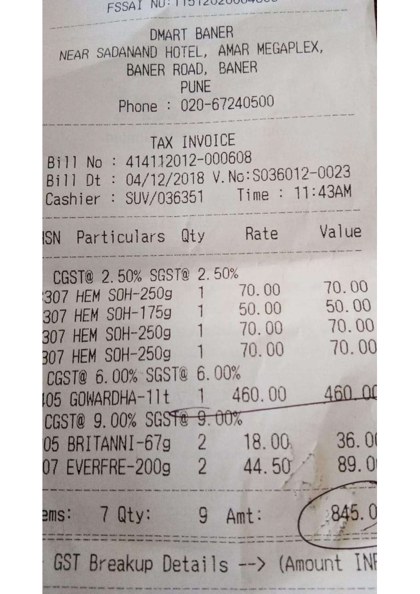

{
  "page": 1,
  "schema_valid": true,
  "receipt": {
    "store_name": "DMART BANER NEAR SADANAND HOTEL, AMAR MEGAPLEX, BANER ROAD, BANER PUNE",
    "date": "04-12-2018",
    "line_items": [
      {
        "name": "307 HEM SOH-250g",
        "qty": 1.0,
        "unit_price": 70.0,
        "amount": 70.0
      },
      {
        "name": "307 HEM SOH-175g",
        "qty": 1.0,
        "unit_price": 50.0,
        "amount": 50.0
      },
      {
        "name": "307 HEM SOH-250g",
        "qty": 1.0,
        "unit_price": 70.0,
        "amount": 70.0
      },
      {
        "name": "307 HEM SOH-250g",
        "qty": 1.0,
        "unit_price": 70.0,
        "amount": 70.0
      },
      {
        "name": "05 GOWARDHA-11t",
        "qty": 1.0,
        "unit_price": 460.0,
        "amount": 460.0
      },
      {
        "name": "05 BRITANNI-67g",
        "qty": 2.0,
        "unit_price": 18.0,
        "amount": 36.0
      },
      {
        "name": "07 EVERFRE-200g",
        "qty": 2.0,
 

/kaggle/working/pdf_predictions/dmart_99de176a_20260930T185419920965Z/predictions.json

In [12]:
pdf_selected_path = pdf_resolve_path(PDF_PATH)
print("Selected PDF:", pdf_selected_path)
pdf_document_results = pdf_run_document(pdf_selected_path, PDF_OUTPUT_DIR)


# Minimal Kaggle API validation



This bundle runs the existing FastAPI backend, not a second notebook-only
extractor. It contains `app/`, the concurrency probe, CPU requirements, package
metadata, and three synthetic sample PDFs. No UI, training notebooks, model
weights, `.env`, or credentials are included. It needs Python 3.11 or newer.

Create a **private Kaggle dataset** from `kaggle-api.zip`, attach it to a fresh
notebook, and enable **GPU** and **Internet**. Attach your own receipt PDF
separately. Run the Python blocks below as separate notebook cells, in order.
Do not load another model in that session: the API subprocess owns the GPU.
Kaggle may unpack the ZIP during dataset creation; both layouts are supported.

## 1. Copy the bundle and install dependencies


In [1]:
import shutil
import subprocess
import sys
import zipfile
from pathlib import Path

if not (sys.version_info >= (3, 11)):
    raise RuntimeError('Python 3.11+ is required.')
BUNDLE_PATH = ""
PROJECT = Path("/kaggle/working/kaggle-api")
if not BUNDLE_PATH:
    roots = sorted({
        path.parent for path in Path("/kaggle/input").rglob("pyproject.toml")
        if (path.parent / "app/main.py").is_file()
    })
    candidates = roots or sorted(Path("/kaggle/input").rglob("kaggle-api.zip"))
    print("Bundle candidates:", *candidates, sep="\n")
    if len(candidates) != 1:
        raise ValueError("Set BUNDLE_PATH to the exact extracted bundle folder or ZIP above.")
    bundle = candidates[0]
else:
    bundle = Path(BUNDLE_PATH)
if PROJECT.exists():
    raise RuntimeError("Project folder already exists. Skip this cell or start a fresh session.")
if bundle.is_dir():
    shutil.copytree(bundle, PROJECT)
else:
    with zipfile.ZipFile(bundle) as archive:
        destination = PROJECT.parent.resolve()
        for entry in archive.infolist():
            target = (destination / entry.filename).resolve()
            if not target.is_relative_to(PROJECT.resolve()):
                raise ValueError("Unexpected archive member outside kaggle-api/.")
        archive.extractall(destination)
if not ((PROJECT / 'app/main.py').is_file()):
    raise RuntimeError("API setup validation failed: (PROJECT / 'app/main.py').is_file()")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(PROJECT / "requirements.txt")])
subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "transformers>=4.57,<5", "peft>=0.19.1,<0.20", "accelerate>=1.2,<2",
    "bitsandbytes>=0.46,<1", "huggingface_hub>=0.34,<1",
])
if not shutil.which("tesseract"):
    subprocess.check_call(["apt-get", "update", "-qq"])
    subprocess.check_call(["apt-get", "install", "-y", "tesseract-ocr", "tesseract-ocr-eng"])
subprocess.check_call(["tesseract", "--version"])
print("Project ready:", PROJECT)


Bundle candidates:
/kaggle/input/datasets/maheshnallada/kaggle-api/kaggle-api
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.6/66.6 kB 1.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opentelemetry-instrumentation-fastapi to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of opentelemetry-instrumentation-fastapi to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is still looking at multiple versions of opentelemetry-sdk to determine which vers

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
sigstore-models 0.0.6 requires pydantic>=2.12, but you have pydantic 2.11.4 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
mcp 1.27.0 requires pyjwt[crypto]>=2.10.1, but you have pyjwt 2.9.0 which is incompatible.
sse-starlette 3.3.4 requires starlette>=0.49.1, but you have starlette 0.46.2 which is incompatible.
google-adk 1.29.0 requires fastapi<1.0.0,>=0.124.1, but you have fastapi 0.115.12 which is incompatible.
google-adk 1.29.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.33.1 which is incompatible.
google-adk 1.29.0 requires opentelemetry-exporter-otlp-proto-http>=1.36.0, but you have opentelemetry-exporter-otlp-proto-http 1.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 12.4 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
tesseract 4.1.1
 leptonica-1.82.0
  libgif 5.1.9 : libjpeg 8d (libjpeg-turbo 2.1.1) : libpng 1.6.37 : libtiff 4.3.0 : zlib 1.2.11 : libwebp 1.2.2 : libopenjp2 2.4.0
 Found AVX512BW
 Found AVX512F
 Found AVX2
 Found AVX
 Found FMA
 Found SSE
 Found libarchive 3.6.0 zlib/1.2.11 liblzma/5.2.5 bz2lib/1.0.8 liblz4/1.9

## 2. Download the adapter and start the real API


In [2]:
import json
import os
import socket
import subprocess
import sys
from pathlib import Path

import torch
from huggingface_hub import snapshot_download

PROJECT = Path("/kaggle/working/kaggle-api")
if not (torch.cuda.is_available()):
    raise RuntimeError('Enable a Kaggle GPU.')
if not (torch.cuda.memory_allocated(0) == 0):
    raise RuntimeError('Restart: another model may be loaded in this notebook.')
ADAPTER_ID = "Mahesh-Nallada/vlm-receipt-extraction-lora"
ADAPTER_REVISION = "e9d1eb7ff9a11273a87a5d27a9fec7ba35b4ee92"
adapter_dir = snapshot_download(
    ADAPTER_ID, revision=ADAPTER_REVISION,
    allow_patterns=["adapter_config.json", "adapter_model.safetensors"],
)
if not ((Path(adapter_dir) / 'adapter_model.safetensors').is_file()):
    raise RuntimeError("API setup validation failed: (Path(adapter_dir) / 'adapter_model.safetensors').is_file()")
OUTPUT = PROJECT / "reports"
OUTPUT.mkdir(exist_ok=True)
with socket.socket() as port_check:
    port_check.bind(("127.0.0.1", 8000))
environment = os.environ.copy()
settings = {
    "MODEL_BACKEND": "qwen",
    "MODEL_ID": "Qwen/Qwen2.5-VL-3B-Instruct",
    "ADAPTER_PATH": adapter_dir,
    "ADAPTER_REVISION": ADAPTER_REVISION,
    "QUEUE_DEPTH": "8",
    "QUEUE_TIMEOUT_S": "60",
    "INFERENCE_TIMEOUT_S": "120",
    "REDIS_URL": "",
    "LOGFIRE_SEND_TO_LOGFIRE": "false",
    "LOGFIRE_TOKEN": "",
    "HF_HOME": "/kaggle/working/hf-cache",
}
environment.update(settings)
(OUTPUT / "run_settings.json").write_text(json.dumps(settings, indent=2))
with (OUTPUT / "api.log").open("w") as log:
    server = subprocess.Popen(
        [sys.executable, "-m", "uvicorn", "app.main:app", "--host", "127.0.0.1", "--port", "8000", "--workers", "1"],
        cwd=PROJECT, env=environment, stdout=log, stderr=subprocess.STDOUT,
    )
print("API PID:", server.pid, "Log:", OUTPUT / "api.log")


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

adapter_model.safetensors:   0%|          | 0.00/120M [00:00<?, ?B/s]

adapter_config.json: 0.00B [00:00, ?B/s]

API PID: 156 Log: /kaggle/working/kaggle-api/reports/api.log


## 3. Wait for readiness and verify the backend


In [3]:
import time
import httpx

BASE_URL = "http://127.0.0.1:8000"
deadline = time.monotonic() + 900
with httpx.Client(timeout=5) as client:
    while True:
        if server.poll() is not None:
            raise RuntimeError(f"API exited with {server.returncode}; inspect {OUTPUT / 'api.log'}.")
        try:
            ready = client.get(BASE_URL + "/ready")
            if ready.status_code == 200:
                break
        except httpx.TransportError:
            pass
        if time.monotonic() >= deadline:
            raise TimeoutError(f"Startup exceeded 15 minutes; inspect {OUTPUT / 'api.log'}.")
        time.sleep(3)
    version = client.get(BASE_URL + "/version")
    version.raise_for_status()
    version_data = version.json()
if not (version_data['backend'] == 'qwen'):
    raise RuntimeError("API setup validation failed: version_data['backend'] == 'qwen'")
if not (version_data['adapter_revision'] == ADAPTER_REVISION):
    raise RuntimeError("API setup validation failed: version_data['adapter_revision'] == ADAPTER_REVISION")
(OUTPUT / "version.json").write_text(json.dumps(version_data, indent=2))
print(version_data)


{'model_id': 'Qwen/Qwen2.5-VL-3B-Instruct', 'adapter_revision': 'e9d1eb7ff9a11273a87a5d27a9fec7ba35b4ee92', 'schema_version': '1.0.0', 'backend': 'qwen', 'prompt_version': '1.0.0'}


## 4. Submit a PDF and save evidence


In [4]:
import time
import httpx

PDF_PATH = PROJECT / "samples/receipt_ok.pdf"
# Example replacement: Path("/kaggle/input/your-private-dataset/dmart.pdf")
started = time.perf_counter()
with PDF_PATH.open("rb") as pdf, httpx.Client(timeout=1500) as client:
    response = client.post(
        BASE_URL + "/extract", data={"force_refresh": "true"},
        files={"file": (PDF_PATH.name, pdf, "application/pdf")},
    )
capture = {
    "filename": PDF_PATH.name,
    "status": response.status_code,
    "elapsed_s": round(time.perf_counter() - started, 3),
    "headers": {key: value for key, value in response.headers.items() if key.lower().startswith("x-")},
    "body": response.text,
}
(OUTPUT / "extraction_capture.json").write_text(json.dumps(capture, indent=2))
print(json.dumps(capture, indent=2))
response.raise_for_status()
(OUTPUT / "receipt.json").write_text(json.dumps(response.json(), indent=2))


{
  "filename": "receipt_ok.pdf",
  "status": 200,
  "elapsed_s": 31.619,
  "headers": {
    "x-request-id": "9307f8f3-390d-48c8-b8e7-7e754059ba21",
    "x-cache": "MISS",
    "x-queue-wait-ms": "0.1",
    "x-inference-ms": "31471.6"
  },
  "body": "{\"store_name\":\"Oak & Ember Cafe\",\"date\":\"2026-03-15\",\"line_items\":[{\"name\":\"Latte\",\"qty\":2.0,\"unit_price\":4.5,\"amount\":9.0},{\"name\":\"Croissant\",\"qty\":1.0,\"unit_price\":3.5,\"amount\":3.5}],\"subtotal\":12.5,\"tax\":1.0,\"total\":13.5,\"_verification\":{\"store_name\":\"verified\",\"date\":\"verified\",\"line_items.0.name\":\"verified\",\"line_items.0.qty\":\"verified\",\"line_items.0.unit_price\":\"verified\",\"line_items.0.amount\":\"verified\",\"line_items.1.name\":\"verified\",\"line_items.1.qty\":\"verified\",\"line_items.1.unit_price\":\"verified\",\"line_items.1.amount\":\"verified\",\"subtotal\":\"verified\",\"tax\":\"verified\",\"total\":\"verified\"}}"
}


802

## 5. Capture concurrent requests


In [5]:
probe = subprocess.run(
    [sys.executable, "scripts/concurrency_test.py", "--base-url", BASE_URL,
     "--pdf", str(PROJECT / "samples/receipt_ok.pdf"),
     "--out", str(OUTPUT / "concurrency_output.txt")],
    cwd=PROJECT, text=True, capture_output=True,
)
(OUTPUT / "concurrency_console.txt").write_text(probe.stdout + probe.stderr)
print(probe.stdout)
if probe.returncode:
    print(probe.stderr)
    raise RuntimeError("Concurrency probe failed; retain the console capture and API log.")


request 1 status=200 cache=MISS queue_wait_ms=0.0 inference_ms=24043.6 elapsed_ms=120273.5
request 2 status=200 cache=MISS queue_wait_ms=0.0 inference_ms=24144.8 elapsed_ms=120270.8
request 3 status=200 cache=MISS queue_wait_ms=0.0 inference_ms=24162.0 elapsed_ms=120273.2
request 4 status=200 cache=MISS queue_wait_ms=0.0 inference_ms=23948.5 elapsed_ms=120272.3
request 5 status=200 cache=MISS queue_wait_ms=0.0 inference_ms=23947.2 elapsed_ms=120272.3
SUMMARY statuses=200,200,200,200,200 max_active_requests=5



## 6. Stop the server


In [6]:
server.terminate()
try:
    server.wait(timeout=40)
except subprocess.TimeoutExpired:
    server.kill()
    server.wait()
print("API stopped. Download evidence from:", OUTPUT)


API stopped. Download evidence from: /kaggle/working/kaggle-api/reports
